# Atobb vs TTLJ XGBoost Training and ONNX Export — senior-tree features

This is a minimally modified copy of the existing notebook.

Main change only:
- use the features stored by the senior `AtobbMLTree` ROOT tree
- do **not** reconstruct `A_mass_best`, `A_dr_best`, etc. from `TARGET_MA`

The rest of the training / weighting / validation / ONNX workflow is kept as close as possible to the original notebook.


## 1. Imports

Run this in the `MLHEP` kernel/environment where `ROOT`, `xgboost`, `onnxmltools`, and `skl2onnx` are installed.


In [1]:
import os
import json
import pickle
import numpy as np
import pandas as pd
import ROOT
import xgboost as xgb
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import roc_curve, auc, accuracy_score, confusion_matrix

# [ADDED] train/validation overtraining test
from scipy.stats import ks_2samp

import onnx
from onnxmltools.convert import convert_xgboost as convert_xgboost_booster
from skl2onnx.common.data_types import FloatTensorType

# [CHANGED]
# Use the same random seed everywhere instead of writing 42 repeatedly.
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

## 2. Input ROOT files

Change these paths if your files are somewhere else.


In [2]:
BASE_DIR = "/data9/Users/bhoh/SKNanoOutput/AtobbMLTree/2024"

SIG_FILES = [
    f"{BASE_DIR}/TTToHcToWAToBB-MHc130_MA36_SingleLepFilter.root",
]

BKG_FILES = [
    f"{BASE_DIR}/TTLJ_powheg.root",
]

TREE_NAME = "Training_Tree"

# ============================================================
# [ADDED] A-mass hypothesis
#
# IMPORTANT:
#   This is the ONLY place where the analysis assumes MA.
#
# AtobbMLTree.cc does NOT know MA anymore.
#
# The exact same TARGET_MA is applied to:
#   - signal
#   - TTLJ
#   - later ttH
#   - later ttZ
#
# Example:
#   MA90 classifier -> TARGET_MA = 90.
#   MA60 classifier -> TARGET_MA = 60.
# ============================================================
TARGET_MHc = 130.0
TARGET_MA = 36.0


MODEL_DIR = "/data9/Users/eunsu/MachineLearning/models"
os.makedirs(MODEL_DIR, exist_ok=True)

# [CHANGED]
# Put the MA hypothesis in the filename so models are not confused later.
MODEL_NAME = f"xgboost_atobb_MHc{int(TARGET_MHc)}_MA{int(TARGET_MA)}_ttlj"


ONNX_PATH = f"{MODEL_DIR}/{MODEL_NAME}.onnx"
FEATURE_JSON_PATH = f"{MODEL_DIR}/{MODEL_NAME}_features.json"
SCALER_JSON_PATH = f"{MODEL_DIR}/{MODEL_NAME}_scaler.json"
SCALER_PICKLE_PATH = f"{MODEL_DIR}/{MODEL_NAME}_scaler.pkl"

# Background statistics test.
# Change this to 10000, 20000, 50000, 100000, or None.
N_BKG = 100000

# Booster scan. Later, choose one value and rerun for the final model.
NUM_BOOST_ROUND = 500  # Try 20, 50, 100, 200, 300

# Preprocessing choice: "standard", "minmax", or None
# ============================================================
# [CHANGED / RECOMMENDED]
#
# XGBoost decision trees do not require feature standardization.
# None is simpler and avoids reproducing StandardScaler in C++.
#
# Use "standard" only if you explicitly want to keep the old setup.
# ============================================================
SCALER_TYPE = None

print("Signal files:")
for p in SIG_FILES:
    print("  ", p, os.path.exists(p))
print("Background files:")
for p in BKG_FILES:
    print("  ", p, os.path.exists(p))


Signal files:
   /data9/Users/bhoh/SKNanoOutput/AtobbMLTree/2024/TTToHcToWAToBB-MHc130_MA36_SingleLepFilter.root True
Background files:
   /data9/Users/bhoh/SKNanoOutput/AtobbMLTree/2024/TTLJ_powheg.root True


## 3. Load ROOT tree into pandas

This function reads only the branches we need, which is faster and safer than reading everything.


In [3]:
def read_training_tree(files, tree_name="Training_Tree", branches=None):
    dfs = []
    for path in files:
        if not os.path.exists(path):
            raise FileNotFoundError(path)
        f = ROOT.TFile.Open(path, "READ")
        if not f or f.IsZombie():
            raise RuntimeError(f"Cannot open ROOT file: {path}")
        tree = f.Get(tree_name)
        if not tree:
            raise RuntimeError(f"Cannot find tree '{tree_name}' in {path}")
        rdf = ROOT.RDataFrame(tree)
        if branches is None:
            arr = rdf.AsNumpy()
        else:
            arr = rdf.AsNumpy(branches)
        df = pd.DataFrame(arr)
        df["source_file"] = os.path.basename(path)
        dfs.append(df)
        f.Close()
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()


## 4. Feature list

First-pass feature set. These are physics-motivated variables from `AtobbMLTree`: jet activity, b-tag topology, bb-pair masses, and ttbar reconstruction variables.

Do **not** include `label`, `weight_*`, or `source_file` as ML inputs.


In [4]:
# ============================================================
# [CHANGED] OLD TARGET_MA-DEPENDENT A RECONSTRUCTION DISABLED
# ============================================================
#
# The previous notebook built:
#
#   A_mass_best, A_dr_best, A_pt_best, ...
#
# by choosing
#
#   argmin |m_bb - TARGET_MA|
#
# among the raw bb pairs.
#
# For this notebook we intentionally DO NOT do that.
#
# The new ROOT files were produced with the senior AtobbMLTree,
# and the senior feature strategy feeds the individual bb
# combinations + higher-level signal-topology masses directly
# to XGBoost.
#
# TARGET_MHc / TARGET_MA are still kept in the input cell only
# for sample/model naming.
# ============================================================


In [5]:
# ============================================================
# 4. Feature configuration
# ============================================================

WEIGHT_COL = "weight_train"
LABEL_COL = "label"

BB_PAIRS = ["01", "02", "12", "03", "13", "23"]


# ============================================================
# Notebook-derived MA-independent bb summary features
# ============================================================

DERIVED_BB_SUMMARY_FEATURES = [
    "bb_mass_min_all", "bb_mass_max_all", "bb_mass_at_min_dr", "bb_dr_min_all"
]


# ============================================================
# [ADDED] TARGET_MA-dependent A-candidate features
#
# Candidate definition:
#
#   best pair = argmin |m_bb - TARGET_MA|
#
# IMPORTANT:
# Exactly the same TARGET_MA and reconstruction are applied
# to signal and background.
#
# First test:
#   use ONLY A_mass_best.
#
# Uncomment additional variables one at a time later.
# ============================================================

DERIVED_A_FEATURES = [
    # "A_mass_best",

    # [OPTIONAL - test later]
    # "A_dr_best",
    # "bb_mass_diff_closest_target",
]


# ============================================================
# Final XGBoost features
# ============================================================

FEATURES = [
    # Event
    "HT", "ST", "MET_Pt",

    # Multiplicity
    "nJets", "nBJets",

    # Lepton
    "Lepton0_Pt", "Lepton0_Eta",

    # --------------------------------------------------------
    # MA-independent bb summaries
    # --------------------------------------------------------
    "bb_mass_min_all", "bb_mass_max_all", "bb_mass_at_min_dr", "bb_dr_min_all",

    # --------------------------------------------------------
    # Direct bb pair information
    #
    # 03/13/23 raw bb mass/dr remain excluded from direct ML
    # input because they strongly encoded the fourth-b topology.
    # --------------------------------------------------------
    "bb_mass_01", "bb_mass_02", "bb_mass_12",
    "bb_dr_01", "bb_dr_02", "bb_dr_12",

    # --------------------------------------------------------
    # [ADDED] TARGET_MA-dependent A candidate
    # --------------------------------------------------------
    # "A_mass_best",

    # [OPTIONAL - uncomment together with DERIVED_A_FEATURES]
    # "A_dr_best",
    # "bb_mass_diff_closest_target",

    # --------------------------------------------------------
    # Composite masses
    # --------------------------------------------------------
    "bblnu_mass_01", "bblnu_mass_02", "bblnu_mass_12",

    # Fourth-b bblnu combinations remain excluded
    # "bblnu_mass_03", "bblnu_mass_13", "bblnu_mass_23",

    "bbjj_mass_01", "bbjj_mass_02", "bbjj_mass_12",
    # "bbjj_mass_03", "bbjj_mass_13", "bbjj_mass_23",

    "bbbW_mass_012", 
    # "bbbW_mass_013", "bbbW_mass_023", "bbbW_mass_123",
    # "bW_mass_013", "bW_mass_023", "bW_mass_123",

    # W reconstruction
    "lnu_mass", "jj_mass",

    # ttbar hypothesis
    "best_chi2", "had_W_mass", "had_top_mass", "lep_W_mass", "lep_top_mass",
]


# ============================================================
# All notebook-derived features
#
# These must NOT be searched for in the ROOT tree.
# ============================================================

DERIVED_FEATURES = DERIVED_BB_SUMMARY_FEATURES + DERIVED_A_FEATURES


# ============================================================
# Auxiliary bb branches
#
# Read all six pairs because they are needed for:
#
#   1. bb summary reconstruction
#   2. TARGET_MA-dependent A candidate reconstruction
#
# 03/13/23 are READ but are not necessarily direct XGBoost
# inputs.
# ============================================================

BB_SOURCE_BRANCHES = [
    "bb_mass_01", "bb_mass_02", "bb_mass_12", "bb_mass_03", "bb_mass_13", "bb_mass_23",
    "bb_dr_01", "bb_dr_02", "bb_dr_12", "bb_dr_03", "bb_dr_13", "bb_dr_23",
]


# ============================================================
# ROOT branches actually required
# ============================================================

ROOT_FEATURES_TO_READ = [
    feat for feat in FEATURES
    if feat not in DERIVED_FEATURES
]

BRANCHES_TO_READ = sorted(set(
    ROOT_FEATURES_TO_READ
    + BB_SOURCE_BRANCHES
    + [WEIGHT_COL, "weight_nominal", LABEL_COL]
))


print(f"Number of final ML features = {len(FEATURES)}")
print(FEATURES)

print()
print(f"Number of ROOT branches to read = {len(BRANCHES_TO_READ)}")
print(BRANCHES_TO_READ)

print()
print("Derived in notebook:", DERIVED_FEATURES)
print("Auxiliary only:", [x for x in BB_SOURCE_BRANCHES if x not in FEATURES])

Number of final ML features = 31
['HT', 'ST', 'MET_Pt', 'nJets', 'nBJets', 'Lepton0_Pt', 'Lepton0_Eta', 'bb_mass_min_all', 'bb_mass_max_all', 'bb_mass_at_min_dr', 'bb_dr_min_all', 'bb_mass_01', 'bb_mass_02', 'bb_mass_12', 'bb_dr_01', 'bb_dr_02', 'bb_dr_12', 'bblnu_mass_01', 'bblnu_mass_02', 'bblnu_mass_12', 'bbjj_mass_01', 'bbjj_mass_02', 'bbjj_mass_12', 'bbbW_mass_012', 'lnu_mass', 'jj_mass', 'best_chi2', 'had_W_mass', 'had_top_mass', 'lep_W_mass', 'lep_top_mass']

Number of ROOT branches to read = 36
['HT', 'Lepton0_Eta', 'Lepton0_Pt', 'MET_Pt', 'ST', 'bb_dr_01', 'bb_dr_02', 'bb_dr_03', 'bb_dr_12', 'bb_dr_13', 'bb_dr_23', 'bb_mass_01', 'bb_mass_02', 'bb_mass_03', 'bb_mass_12', 'bb_mass_13', 'bb_mass_23', 'bbbW_mass_012', 'bbjj_mass_01', 'bbjj_mass_02', 'bbjj_mass_12', 'bblnu_mass_01', 'bblnu_mass_02', 'bblnu_mass_12', 'best_chi2', 'had_W_mass', 'had_top_mass', 'jj_mass', 'label', 'lep_W_mass', 'lep_top_mass', 'lnu_mass', 'nBJets', 'nJets', 'weight_nominal', 'weight_train']

Derived i

In [6]:
# ============================================================
# 5. Reconstruct MA-independent bb summary features
# ============================================================

def add_bb_summary_features(df):
    out = df.copy()

    mass_cols = [f"bb_mass_{pair}" for pair in BB_PAIRS]
    dr_cols = [f"bb_dr_{pair}" for pair in BB_PAIRS]

    masses = out[mass_cols].to_numpy(dtype=float)
    drs = out[dr_cols].to_numpy(dtype=float)

    # mass/dr가 둘 다 physical한 pair만 사용
    valid = np.isfinite(masses) & np.isfinite(drs) & (masses > 0.0) & (drs > 0.0)
    has_valid_pair = np.any(valid, axis=1)

    # min/max bb mass
    out["bb_mass_min_all"] = np.min(np.where(valid, masses, np.inf), axis=1)
    out["bb_mass_max_all"] = np.max(np.where(valid, masses, -np.inf), axis=1)

    # minimum DeltaR pair
    dr_for_min = np.where(valid, drs, np.inf)
    min_dr_idx = np.argmin(dr_for_min, axis=1)
    row_idx = np.arange(len(out))

    out["bb_dr_min_all"] = drs[row_idx, min_dr_idx]
    out["bb_mass_at_min_dr"] = masses[row_idx, min_dr_idx]

    # valid pair 자체가 없는 event
    derived_cols = ["bb_mass_min_all", "bb_mass_max_all", "bb_mass_at_min_dr", "bb_dr_min_all"]
    out.loc[~has_valid_pair, derived_cols] = np.nan

    return out

In [7]:
# ============================================================
# [ADDED] TARGET_MA-dependent A candidate reconstruction
#
# Among all valid bb pairs:
#
#     best pair = argmin |m_bb - TARGET_MA|
#
# The same reconstruction is applied to signal and background.
# ============================================================

def add_target_ma_features(df, target_ma):
    out = df.copy()

    mass_cols = [f"bb_mass_{pair}" for pair in BB_PAIRS]
    dr_cols = [f"bb_dr_{pair}" for pair in BB_PAIRS]

    masses = out[mass_cols].to_numpy(dtype=float)
    drs = out[dr_cols].to_numpy(dtype=float)

    # Valid pair:
    # reject NaN / inf / 0 / -999 placeholders
    valid = (
        np.isfinite(masses)
        & np.isfinite(drs)
        & (masses > 0.0)
        & (drs > 0.0)
    )

    has_valid_pair = np.any(valid, axis=1)

    # Distance from target A mass
    mass_diff = np.where(valid, np.abs(masses - target_ma), np.inf)

    # Pair closest to TARGET_MA
    best_idx = np.argmin(mass_diff, axis=1)
    row_idx = np.arange(len(out))

    # --------------------------------------------------------
    # Useful debugging information
    # --------------------------------------------------------
    pair_names = np.array(BB_PAIRS)

    out["A_pair_name"] = pair_names[best_idx]

    # --------------------------------------------------------
    # Derived A features
    # --------------------------------------------------------
    out["A_mass_best"] = masses[row_idx, best_idx]
    out["A_dr_best"] = drs[row_idx, best_idx]
    out["bb_mass_diff_closest_target"] = mass_diff[row_idx, best_idx]

    # Safety
    out.loc[~has_valid_pair, "A_pair_name"] = "none"
    out.loc[
        ~has_valid_pair,
        ["A_mass_best", "A_dr_best", "bb_mass_diff_closest_target"],
    ] = np.nan

    return out

In [8]:
# ============================================================
# 6. ROOT branch check
# ============================================================

def check_required_branches(root_path, tree_name, required_branches):
    f = ROOT.TFile.Open(root_path, "READ")
    if not f or f.IsZombie():
        raise RuntimeError(f"Cannot open ROOT file: {root_path}")

    tree = f.Get(tree_name)
    if not tree:
        f.Close()
        raise RuntimeError(f"Cannot find tree '{tree_name}' in {root_path}")

    available = {b.GetName() for b in tree.GetListOfBranches()}
    missing = [b for b in required_branches if b not in available]

    print(f"\nROOT: {root_path}")
    print(f"  available branches = {len(available)}")
    print(f"  required branches  = {len(required_branches)}")

    if missing:
        print("  [MISSING]", missing)
        f.Close()
        raise RuntimeError("Required ROOT branches are missing.")

    print("  [OK] all requested branches exist")
    f.Close()

check_required_branches(SIG_FILES[0], TREE_NAME, BRANCHES_TO_READ)
check_required_branches(BKG_FILES[0], TREE_NAME, BRANCHES_TO_READ)


ROOT: /data9/Users/bhoh/SKNanoOutput/AtobbMLTree/2024/TTToHcToWAToBB-MHc130_MA36_SingleLepFilter.root
  available branches = 129
  required branches  = 36
  [OK] all requested branches exist

ROOT: /data9/Users/bhoh/SKNanoOutput/AtobbMLTree/2024/TTLJ_powheg.root
  available branches = 129
  required branches  = 36
  [OK] all requested branches exist


In [9]:
# ============================================================
# 7. Read signal and background
# ============================================================

df_sig = read_training_tree(SIG_FILES, TREE_NAME, branches=BRANCHES_TO_READ)
df_bkg = read_training_tree(BKG_FILES, TREE_NAME, branches=BRANCHES_TO_READ)

# Reconstruct notebook-derived bb summary features
df_sig = add_bb_summary_features(df_sig)
df_bkg = add_bb_summary_features(df_bkg)

df_sig = add_target_ma_features(df_sig, TARGET_MA)
df_bkg = add_target_ma_features(df_bkg, TARGET_MA)

# Explicit labels
df_sig[LABEL_COL] = 1
df_bkg[LABEL_COL] = 0

print("Before background limit:")
print("  signal entries:", len(df_sig))
print("  bkg entries   :", len(df_bkg))

if N_BKG is not None and len(df_bkg) > N_BKG:
    df_bkg = df_bkg.sample(n=N_BKG, random_state=RANDOM_SEED).reset_index(drop=True)

print("After background limit:")
print("  signal entries:", len(df_sig))
print("  bkg entries   :", len(df_bkg))

# Final safety check
missing_sig = [x for x in FEATURES if x not in df_sig.columns]
missing_bkg = [x for x in FEATURES if x not in df_bkg.columns]

print("Missing final signal features:", missing_sig)
print("Missing final background features:", missing_bkg)

assert not missing_sig
assert not missing_bkg

Before background limit:
  signal entries: 14207
  bkg entries   : 224928
After background limit:
  signal entries: 14207
  bkg entries   : 100000
Missing final signal features: []
Missing final background features: []


## 5. Read signal and background samples

For this notebook, we override the label explicitly to avoid relying on sample-name parsing.


In [10]:
# ============================================================
# [CHANGED] Senior-tree feature sanity check
#
# Replaces the old A_pair_name / A_mass_best debugging cell.
# ============================================================

CHECK_COLS = [
    "nJets",
    "nBJets",
    "bb_mass_01",
    "bb_mass_02",
    "bb_mass_12",
    # "bb_mass_03",
    "bb_dr_01",
    "bb_dr_02",
    "bb_dr_12",
    # "bb_dr_03",
    "bblnu_mass_01",
    "bbjj_mass_01",
    "bbbW_mass_012",
    # "bW_mass_013",
    "lnu_mass",
    "jj_mass",

    # [ADDED] A candidate sanity check
    # "A_pair_name", "A_mass_best", "A_dr_best", "bb_mass_diff_closest_target",
]

print("[Signal]")
display(df_sig[CHECK_COLS].head(10))

print("\n[Background]")
display(df_bkg[CHECK_COLS].head(10))


[Signal]


,nJets,nBJets,bb_mass_01,bb_mass_02,bb_mass_12,bb_dr_01,bb_dr_02,bb_dr_12,bblnu_mass_01,bbjj_mass_01,bbbW_mass_012,lnu_mass,jj_mass
0,9,3,194.933136,206.859070,53.668213,2.078406,2.885476,0.883277,321.216278,414.334320,398.706573,81.630173,47.064640
1,11,4,209.045029,115.747772,96.628426,2.664703,1.149890,1.999578,449.630737,317.223633,377.949921,131.260422,34.440914
2,10,4,107.261719,149.870850,85.609573,2.284358,3.167416,1.873356,336.444336,424.870361,494.083710,121.140228,136.797592
3,9,3,591.917908,113.502869,226.550415,3.020983,0.453619,2.937733,790.493774,880.845581,849.092957,102.980972,130.812515
4,6,3,359.690765,397.882935,71.102173,2.443054,2.690217,0.550970,501.506439,649.424805,645.769470,32.531372,202.171570
5,7,4,155.862228,174.654633,50.045284,2.916189,2.925057,0.748751,286.800873,503.668884,363.398590,106.348427,267.185059
6,7,3,102.268974,153.275925,33.090927,2.234952,3.302912,1.084846,251.231216,740.078369,318.457672,75.465034,609.451111
7,10,3,90.913483,86.059799,78.081825,1.272961,2.626452,3.130478,257.198669,277.864807,294.543518,40.528000,135.993118
8,9,3,49.525753,91.448814,91.758553,2.009624,2.368409,2.707874,176.712708,680.724365,239.692200,50.054085,440.989685
9,9,4,126.872215,109.444817,49.013546,2.557612,2.602792,1.380823,260.940887,328.906189,292.005249,14.636901,186.728058



[Background]


,nJets,nBJets,bb_mass_01,bb_mass_02,bb_mass_12,bb_dr_01,bb_dr_02,bb_dr_12,bblnu_mass_01,bbjj_mass_01,bbbW_mass_012,lnu_mass,jj_mass
0,8,3,405.109070,210.181931,125.648766,2.977167,2.131197,1.451683,502.398926,630.490601,584.286865,33.963837,136.718918
1,10,3,144.416016,114.569817,118.872246,1.212997,2.281724,2.979152,816.022583,1729.034058,860.083130,262.988861,1458.168457
2,9,3,182.060486,170.055206,96.691086,2.717481,2.580737,1.605147,432.247437,499.032990,540.999695,220.476608,121.892830
3,10,3,84.359215,124.301918,52.814594,0.845240,2.134167,1.323243,346.922211,812.615479,405.080566,160.524033,458.836029
4,13,3,191.866913,132.391205,69.467537,2.598781,2.800606,1.491486,315.312439,657.801636,361.245422,41.578506,233.430130
5,9,3,312.864594,93.226112,37.847847,3.472315,2.776726,0.784543,462.827271,588.331177,483.803680,63.323067,83.144463
6,7,3,173.625671,132.357697,70.304787,1.984970,1.836716,2.136147,404.259735,579.083496,464.974762,99.975494,73.793549
7,8,3,79.543076,112.914070,95.287590,1.038685,1.416949,2.259332,253.315262,404.064178,299.664215,48.872551,81.717743
8,8,3,307.720001,205.527786,105.311409,1.602289,1.448953,1.078420,494.550323,1826.051025,572.569885,59.294491,1194.856934
9,10,3,154.161499,91.992424,71.694115,3.512046,2.004839,2.600752,394.468964,616.704651,419.818024,78.650330,431.643707


## 6. Basic cleaning and weight handling

- Replace `inf` with `NaN`
- Drop rows with invalid feature/weight values
- Use `abs(weight_train)` by default for training stability
- Normalize total signal/background weights to similar scale

If you want signed MC weights later, keep them for final histograms, but for first classifier training this is safer.


In [11]:
def print_bad_values(df, features, name):
    print(f"[{name}] bad / placeholder value check")

    for feat in features:
        values = df[feat]

        n_nan = values.isna().sum()
        n_inf = np.isinf(values).sum()
        n_sentinel = (values <= -998).sum()
        n_zero = (values == 0).sum()

        if n_nan or n_inf or n_sentinel or n_zero:
            print(
                f"  {feat:25s} "
                f"NaN={n_nan:6d}, "
                f"Inf={n_inf:6d}, "
                f"<=-998={n_sentinel:6d}, "
                f"zero={n_zero:6d}"
            )

print_bad_values(df_sig, FEATURES, "signal raw")
print_bad_values(df_bkg, FEATURES, "bkg raw")


[signal raw] bad / placeholder value check
  bbjj_mass_01              NaN=     0, Inf=     0, <=-998=    19, zero=     0
  bbjj_mass_02              NaN=     0, Inf=     0, <=-998=    19, zero=     0
  bbjj_mass_12              NaN=     0, Inf=     0, <=-998=    19, zero=     0
  bbbW_mass_012             NaN=     0, Inf=     0, <=-998=     0, zero=    19
  jj_mass                   NaN=     0, Inf=     0, <=-998=     0, zero=    19
  best_chi2                 NaN=     0, Inf=     0, <=-998=   789, zero=     0
  had_W_mass                NaN=     0, Inf=     0, <=-998=   789, zero=     0
  had_top_mass              NaN=     0, Inf=     0, <=-998=   789, zero=     0
  lep_W_mass                NaN=     0, Inf=     0, <=-998=   789, zero=     0
  lep_top_mass              NaN=     0, Inf=     0, <=-998=   789, zero=     0
[bkg raw] bad / placeholder value check
  bbjj_mass_01              NaN=     0, Inf=     0, <=-998=    29, zero=     0
  bbjj_mass_02              NaN=     0, Inf=    

In [12]:
# ============================================================
# DEBUG: find which feature is killing all events
# ============================================================

def check_features_before_cleaning(df, features, name):

    print(f"\n========== {name} ==========")
    print("Total entries:", len(df))

    for feat in features:

        if feat not in df.columns:
            print(f"[MISSING COLUMN] {feat}")
            continue

        values = df[feat]

        n_total = len(values)
        n_nan = values.isna().sum()
        n_inf = np.isinf(values).sum()
        n_sentinel = (values <= -998).sum()
        n_valid = (
            np.isfinite(values)
            & (values > -998)
        ).sum()

        print(
            f"{feat:35s} "
            f"valid={n_valid:7d}  "
            f"sentinel={n_sentinel:7d}  "
            f"nan={n_nan:7d}  "
            f"inf={n_inf:7d}"
        )


check_features_before_cleaning(
    df_sig,
    FEATURES,
    "SIGNAL"
)

check_features_before_cleaning(
    df_bkg,
    FEATURES,
    "BACKGROUND"
)


========== SIGNAL ==========
Total entries: 14207
HT                                  valid=  14207  sentinel=      0  nan=      0  inf=      0
ST                                  valid=  14207  sentinel=      0  nan=      0  inf=      0
MET_Pt                              valid=  14207  sentinel=      0  nan=      0  inf=      0
nJets                               valid=  14207  sentinel=      0  nan=      0  inf=      0
nBJets                              valid=  14207  sentinel=      0  nan=      0  inf=      0
Lepton0_Pt                          valid=  14207  sentinel=      0  nan=      0  inf=      0
Lepton0_Eta                         valid=  14207  sentinel=      0  nan=      0  inf=      0
bb_mass_min_all                     valid=  14207  sentinel=      0  nan=      0  inf=      0
bb_mass_max_all                     valid=  14207  sentinel=      0  nan=      0  inf=      0
bb_mass_at_min_dr                   valid=  14207  sentinel=      0  nan=      0  inf=      0
bb_dr_min

lep_W_mass                          valid=  94324  sentinel=   5676  nan=      0  inf=      0
lep_top_mass                        valid=  94324  sentinel=   5676  nan=      0  inf=      0


In [13]:
print("\n".join(FEATURES))

HT
ST
MET_Pt
nJets
nBJets
Lepton0_Pt
Lepton0_Eta
bb_mass_min_all
bb_mass_max_all
bb_mass_at_min_dr
bb_dr_min_all
bb_mass_01
bb_mass_02
bb_mass_12
bb_dr_01
bb_dr_02
bb_dr_12
bblnu_mass_01
bblnu_mass_02
bblnu_mass_12
bbjj_mass_01
bbjj_mass_02
bbjj_mass_12
bbbW_mass_012
lnu_mass
jj_mass
best_chi2
had_W_mass
had_top_mass
lep_W_mass
lep_top_mass


In [14]:
# ============================================================
# Cleaning and training-weight preparation
#
# [MINIMAL CHANGE FOR SENIOR FEATURES]
#
# The weighting / class balancing below is kept the same as in
# the original notebook.
#
# Only missing-value treatment changes:
#
#   - -999-like sentinels are converted to NaN
#   - rows are NOT dropped merely because an ML feature is NaN
#   - label / event weight must still be valid
#
# XGBoost handles NaN natively.
#
# This matters because features involving the fourth b jet can
# legitimately be unavailable in nBJets == 3 events.
#
# NOTE:
# In the senior tree some unavailable 4th-b combinations may be
# stored as 0 rather than -999. We keep those zeros unchanged here
# to reproduce the tree content as directly as possible.
# The debug cell above prints the zero counts so this is visible.
# ============================================================

def clean_df(df, features, weight_col):

    use_cols = features + [LABEL_COL, weight_col]
    out = df[use_cols].copy()

    # --------------------------------------------------------
    # [1] +/-inf -> NaN
    # --------------------------------------------------------
    out = out.replace([np.inf, -np.inf], np.nan)

    # --------------------------------------------------------
    # [2] -999-like sentinel -> NaN
    #
    # Do NOT drop the whole event because of one missing
    # combination. XGBoost can route NaN through a learned
    # default direction.
    # --------------------------------------------------------
    for feat in features:
        out.loc[out[feat] <= -998, feat] = np.nan

    # --------------------------------------------------------
    # [3] Label and original event weight MUST exist.
    #
    # Feature NaNs are intentionally allowed.
    # --------------------------------------------------------
    out = out.dropna(
        subset=[LABEL_COL, weight_col]
    ).copy()

    # --------------------------------------------------------
    # [4] Prepare training weight
    #
    # Keep original weight_train unchanged for reference.
    # Use |weight_train| for classifier training.
    # --------------------------------------------------------
    out[weight_col] = out[weight_col].astype(float)
    out["ml_weight"] = np.abs(out[weight_col])

    # --------------------------------------------------------
    # [5] Remove unusable / zero weights
    # --------------------------------------------------------
    out = out[
        np.isfinite(out["ml_weight"])
        & (out["ml_weight"] > 0)
    ].copy()

    return out


# Apply exactly the same cleaning to signal and background
df_sig_clean = clean_df(
    df_sig,
    FEATURES,
    WEIGHT_COL,
)

df_bkg_clean = clean_df(
    df_bkg,
    FEATURES,
    WEIGHT_COL,
)

sig_sumw = df_sig_clean["ml_weight"].sum()
bkg_sumw = df_bkg_clean["ml_weight"].sum()

if sig_sumw <= 0 or bkg_sumw <= 0:
    raise RuntimeError(
        f"Invalid total training weight: "
        f"signal={sig_sumw}, background={bkg_sumw}"
    )

# Keep the original class-total-weight balancing unchanged.
n_sig = len(df_sig_clean)
n_bkg = len(df_bkg_clean)
target_sumw_each = 0.5 * (n_sig + n_bkg)

df_sig_clean["ml_weight"] *= target_sumw_each / sig_sumw
df_bkg_clean["ml_weight"] *= target_sumw_each / bkg_sumw

print("After cleaning:")
print("  signal entries:", n_sig, "sum ml weight:", df_sig_clean["ml_weight"].sum())
print("  bkg entries   :", n_bkg, "sum ml weight:", df_bkg_clean["ml_weight"].sum())

print("Raw weight summary:")
print("signal weight_train")
print(df_sig_clean[WEIGHT_COL].describe())
print("background weight_train")
print(df_bkg_clean[WEIGHT_COL].describe())

print("ML weight summary:")
print("signal ml_weight")
print(df_sig_clean["ml_weight"].describe())
print("background ml_weight")
print(df_bkg_clean["ml_weight"].describe())


After cleaning:
  signal entries: 14207 sum ml weight: 57103.5
  bkg entries   : 100000 sum ml weight: 57103.5
Raw weight summary:
signal weight_train
count    14207.000000
mean      1063.897011
std        652.031058
min        248.951721
25%        727.821167
50%        879.023193
75%       1293.715515
max      11177.492188
Name: weight_train, dtype: float64
background weight_train
count    100000.000000
mean          0.089400
std           0.057378
min          -0.322007
25%           0.060918
50%           0.073233
75%           0.109438
max           2.397355
Name: weight_train, dtype: float64
ML weight summary:
signal ml_weight
count    14207.000000
mean         4.019392
std          2.463367
min          0.940537
25%          2.749701
50%          3.320940
75%          4.887644
max         42.228449
Name: ml_weight, dtype: float64
background ml_weight
count    100000.000000
mean          0.571035
std           0.356637
min           0.124043
25%           0.386773
50%           0

## 7. Quick sanity plots

These are not for final presentation, just to confirm signal/background shape differences.


In [15]:
# ============================================================
# 8. Feature sanity check
# ============================================================

CHECK_COLS = [
    "nJets", "nBJets",
    "bb_mass_01", "bb_mass_02", "bb_mass_12", 
    #"bb_mass_03", "bb_mass_13", "bb_mass_23",
    "bb_dr_01", "bb_dr_02", "bb_dr_12", 
    # "bb_dr_03", "bb_dr_13", "bb_dr_23",
    "bb_mass_min_all", "bb_mass_max_all", "bb_mass_at_min_dr", "bb_dr_min_all",
    "bblnu_mass_01", "bbjj_mass_01", "bbbW_mass_012", 
    # "bW_mass_013", 
    "lnu_mass", "jj_mass",
    # "A_mass_best",
]

print("[Signal]")
display(df_sig[CHECK_COLS].head(10))

print("\n[Background]")
display(df_bkg[CHECK_COLS].head(10))

[Signal]


,nJets,nBJets,bb_mass_01,bb_mass_02,bb_mass_12,bb_dr_01,bb_dr_02,bb_dr_12,bb_mass_min_all,bb_mass_max_all,bb_mass_at_min_dr,bb_dr_min_all,bblnu_mass_01,bbjj_mass_01,bbbW_mass_012,lnu_mass,jj_mass
0,9,3,194.933136,206.859070,53.668213,2.078406,2.885476,0.883277,53.668213,206.859070,53.668213,0.883277,321.216278,414.334320,398.706573,81.630173,47.064640
1,11,4,209.045029,115.747772,96.628426,2.664703,1.149890,1.999578,20.689972,209.045029,20.689972,0.567388,449.630737,317.223633,377.949921,131.260422,34.440914
2,10,4,107.261719,149.870850,85.609573,2.284358,3.167416,1.873356,55.125847,149.870850,55.125847,1.099894,336.444336,424.870361,494.083710,121.140228,136.797592
3,9,3,591.917908,113.502869,226.550415,3.020983,0.453619,2.937733,113.502869,591.917908,113.502869,0.453619,790.493774,880.845581,849.092957,102.980972,130.812515
4,6,3,359.690765,397.882935,71.102173,2.443054,2.690217,0.550970,71.102173,397.882935,71.102173,0.550970,501.506439,649.424805,645.769470,32.531372,202.171570
5,7,4,155.862228,174.654633,50.045284,2.916189,2.925057,0.748751,50.045284,179.989197,50.045284,0.748751,286.800873,503.668884,363.398590,106.348427,267.185059
6,7,3,102.268974,153.275925,33.090927,2.234952,3.302912,1.084846,33.090927,153.275925,33.090927,1.084846,251.231216,740.078369,318.457672,75.465034,609.451111
7,10,3,90.913483,86.059799,78.081825,1.272961,2.626452,3.130478,78.081825,90.913483,90.913483,1.272961,257.198669,277.864807,294.543518,40.528000,135.993118
8,9,3,49.525753,91.448814,91.758553,2.009624,2.368409,2.707874,49.525753,91.758553,49.525753,2.009624,176.712708,680.724365,239.692200,50.054085,440.989685
9,9,4,126.872215,109.444817,49.013546,2.557612,2.602792,1.380823,29.972204,126.872215,29.972204,1.007470,260.940887,328.906189,292.005249,14.636901,186.728058



[Background]


,nJets,nBJets,bb_mass_01,bb_mass_02,bb_mass_12,bb_dr_01,bb_dr_02,bb_dr_12,bb_mass_min_all,bb_mass_max_all,bb_mass_at_min_dr,bb_dr_min_all,bblnu_mass_01,bbjj_mass_01,bbbW_mass_012,lnu_mass,jj_mass
0,8,3,405.109070,210.181931,125.648766,2.977167,2.131197,1.451683,125.648766,405.109070,125.648766,1.451683,502.398926,630.490601,584.286865,33.963837,136.718918
1,10,3,144.416016,114.569817,118.872246,1.212997,2.281724,2.979152,114.569817,144.416016,144.416016,1.212997,816.022583,1729.034058,860.083130,262.988861,1458.168457
2,9,3,182.060486,170.055206,96.691086,2.717481,2.580737,1.605147,96.691086,182.060486,96.691086,1.605147,432.247437,499.032990,540.999695,220.476608,121.892830
3,10,3,84.359215,124.301918,52.814594,0.845240,2.134167,1.323243,52.814594,124.301918,84.359215,0.845240,346.922211,812.615479,405.080566,160.524033,458.836029
4,13,3,191.866913,132.391205,69.467537,2.598781,2.800606,1.491486,69.467537,191.866913,69.467537,1.491486,315.312439,657.801636,361.245422,41.578506,233.430130
5,9,3,312.864594,93.226112,37.847847,3.472315,2.776726,0.784543,37.847847,312.864594,37.847847,0.784543,462.827271,588.331177,483.803680,63.323067,83.144463
6,7,3,173.625671,132.357697,70.304787,1.984970,1.836716,2.136147,70.304787,173.625671,132.357697,1.836716,404.259735,579.083496,464.974762,99.975494,73.793549
7,8,3,79.543076,112.914070,95.287590,1.038685,1.416949,2.259332,79.543076,112.914070,79.543076,1.038685,253.315262,404.064178,299.664215,48.872551,81.717743
8,8,3,307.720001,205.527786,105.311409,1.602289,1.448953,1.078420,105.311409,307.720001,105.311409,1.078420,494.550323,1826.051025,572.569885,59.294491,1194.856934
9,10,3,154.161499,91.992424,71.694115,3.512046,2.004839,2.600752,71.694115,154.161499,91.992424,2.004839,394.468964,616.704651,419.818024,78.650330,431.643707


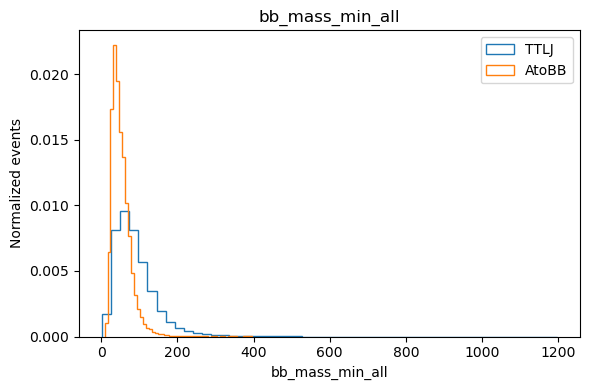

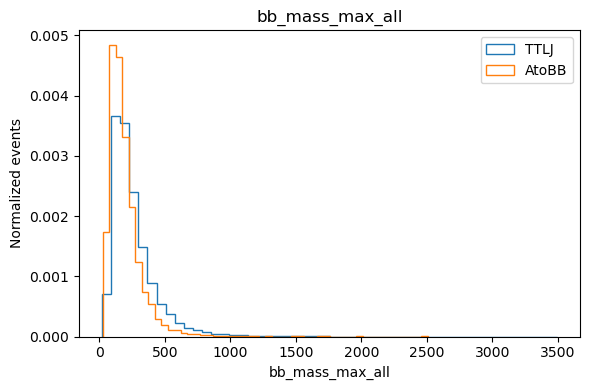

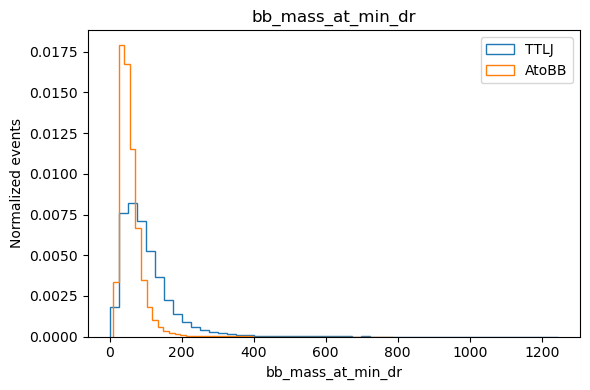

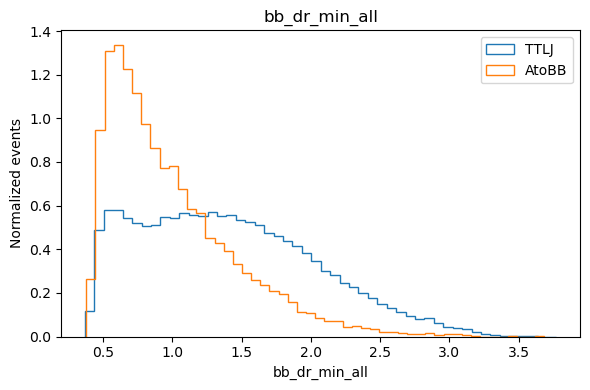

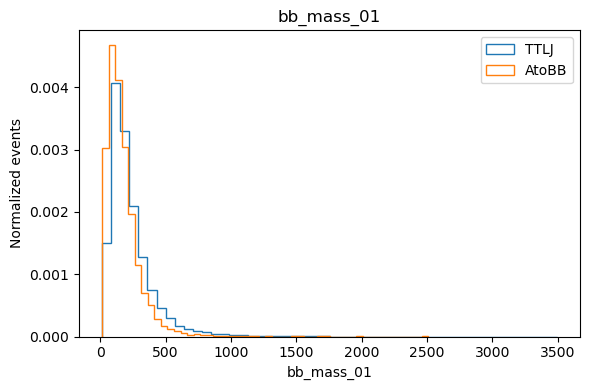

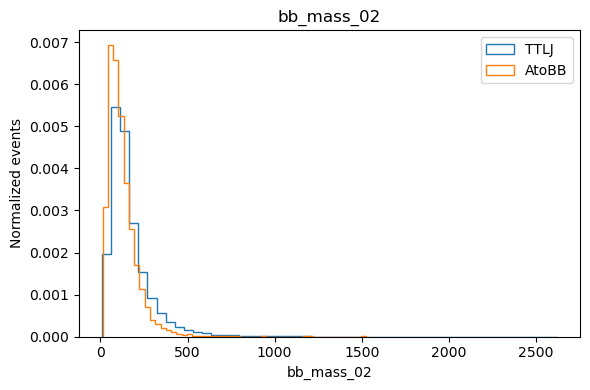

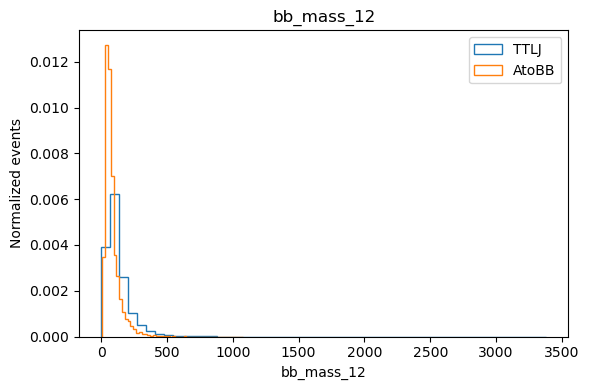

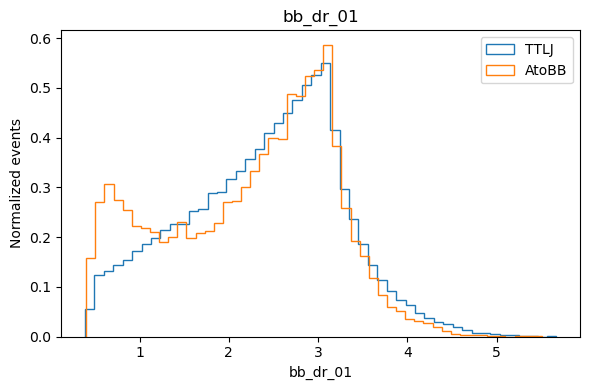

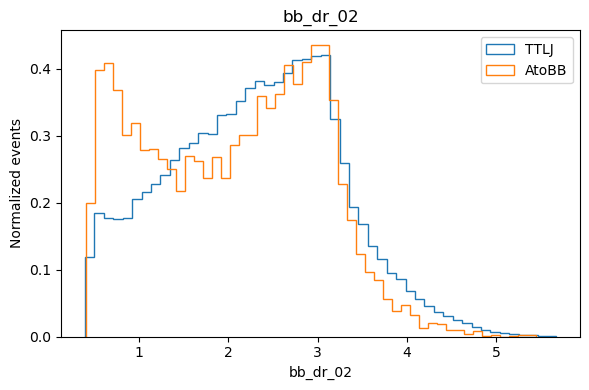

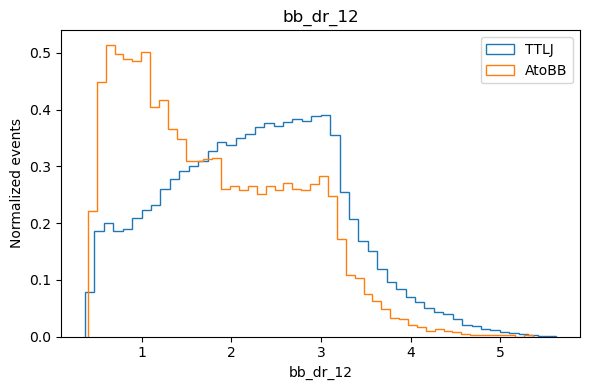

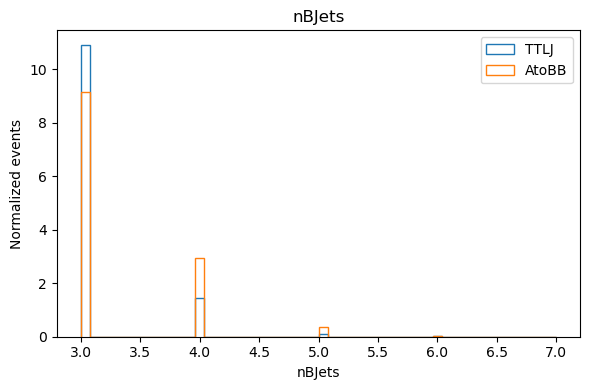

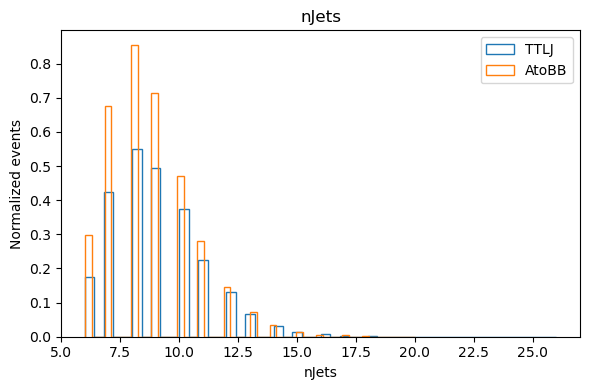

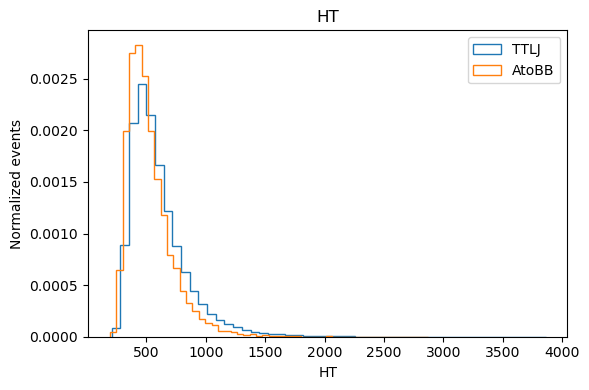

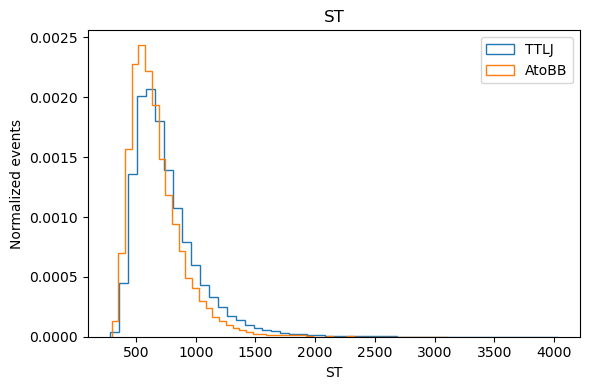

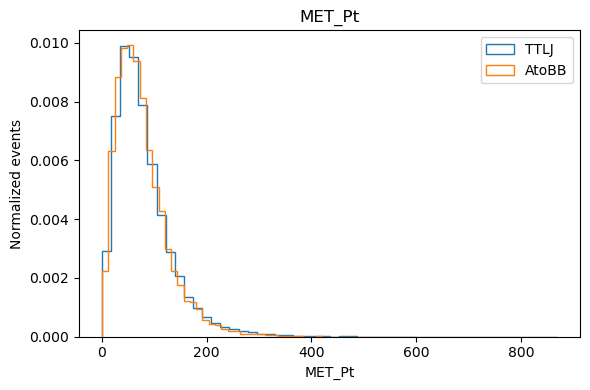

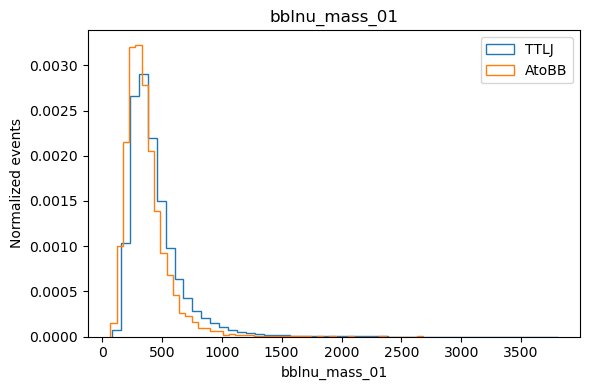

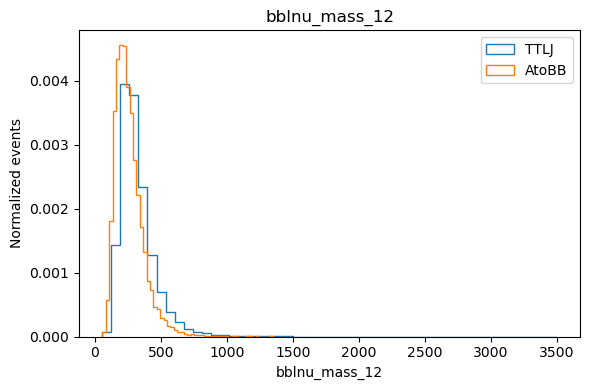

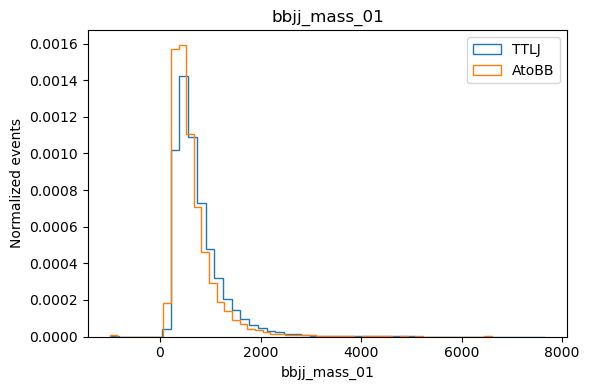

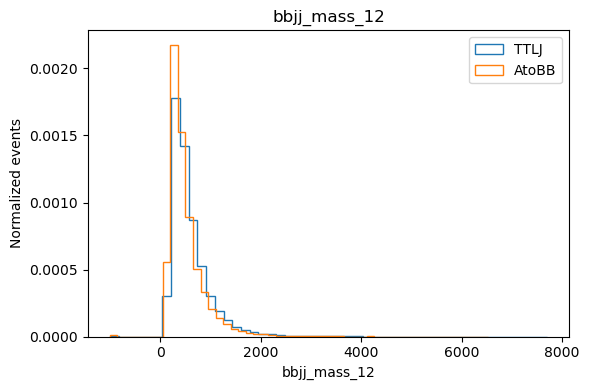

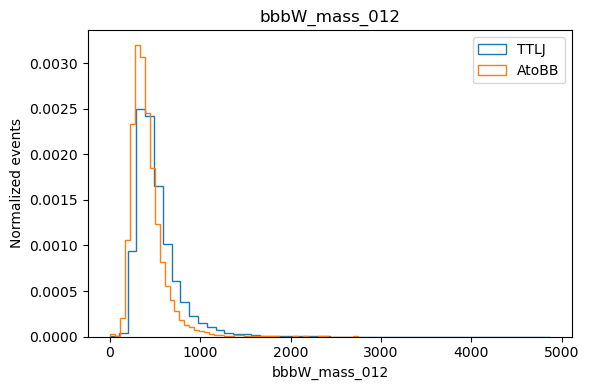

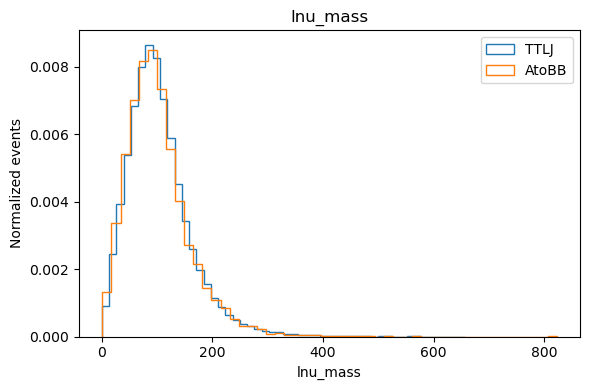

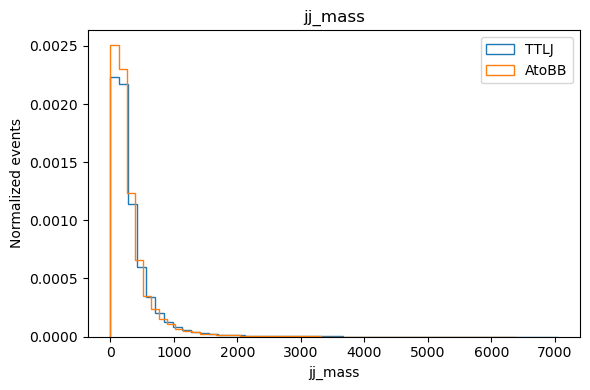

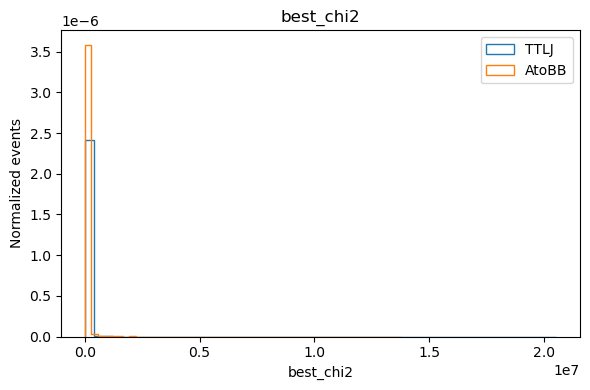

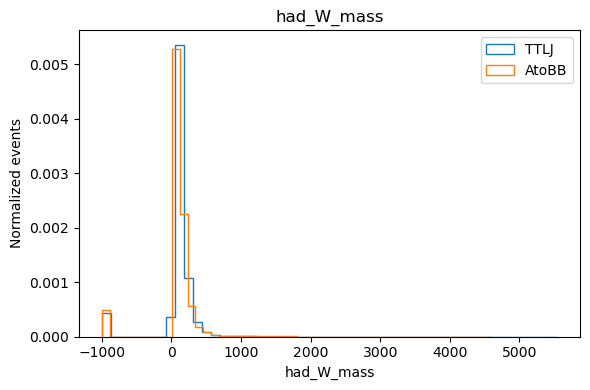

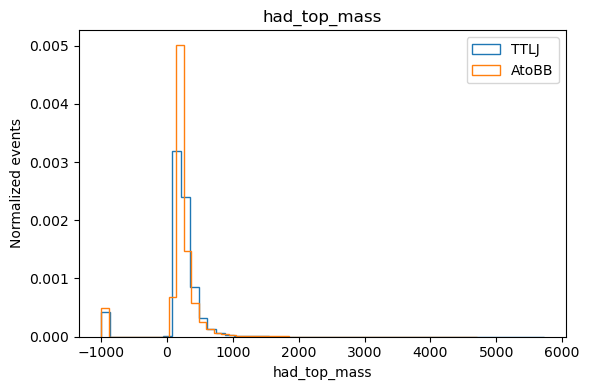

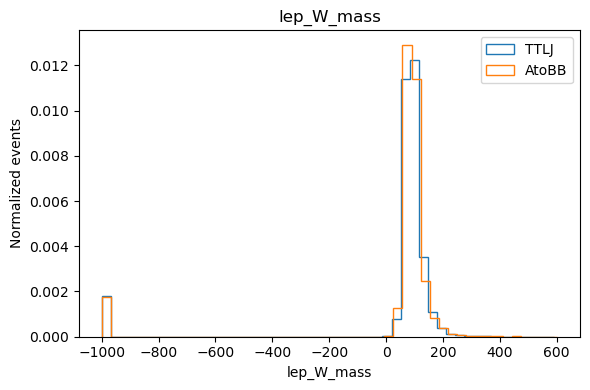

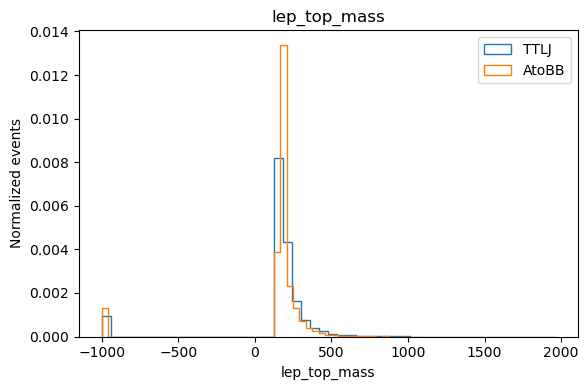

In [16]:
# ============================================================
# 9. Sanity plots before cleaning/training
# ============================================================

def plot_feature(sig, bkg, feature, bins=50, x_range=None, logy=False):
    plt.figure(figsize=(6, 4))
    plt.hist(bkg[feature].replace([np.inf, -np.inf], np.nan).dropna(), bins=bins, range=x_range, histtype="step", density=True, label="TTLJ")
    plt.hist(sig[feature].replace([np.inf, -np.inf], np.nan).dropna(), bins=bins, range=x_range, histtype="step", density=True, label="AtoBB")

    if logy:
        plt.yscale("log")

    plt.xlabel(feature)
    plt.ylabel("Normalized events")
    plt.title(feature)
    plt.legend()
    plt.tight_layout()
    plt.show()

PLOT_FEATURES = [
    # Restored summary features
    "bb_mass_min_all", "bb_mass_max_all", "bb_mass_at_min_dr", "bb_dr_min_all",

    # Direct bb inputs
    "bb_mass_01", "bb_mass_02", "bb_mass_12",
    "bb_dr_01", "bb_dr_02", "bb_dr_12",

    # Event topology
    "nBJets", "nJets", "HT", "ST", "MET_Pt",

    # Composite masses
    "bblnu_mass_01", "bblnu_mass_12",
    "bbjj_mass_01", "bbjj_mass_12",
    "bbbW_mass_012", 
    # "bW_mass_013",
    "lnu_mass", "jj_mass",

    # ttbar reconstruction
    "best_chi2", "had_W_mass", "had_top_mass", "lep_W_mass", "lep_top_mass",

    # "A_mass_best",
]

for feat in PLOT_FEATURES:
    plot_feature(df_sig, df_bkg, feat, bins=50)

In [17]:
from sklearn.metrics import roc_auc_score

all_auc = []

for feat in FEATURES:

    sig = df_sig_clean[feat].to_numpy(dtype=float)
    bkg = df_bkg_clean[feat].to_numpy(dtype=float)

    # ========================================================
    # [CHANGED]
    # XGBoost can train with NaN, but roc_auc_score cannot.
    # For this one-feature diagnostic only, remove non-finite
    # values feature-by-feature.
    # ========================================================
    sig = sig[np.isfinite(sig)]
    bkg = bkg[np.isfinite(bkg)]

    if len(sig) == 0 or len(bkg) == 0:
        print(f"[SKIP] {feat}: no finite signal/background values")
        continue

    y_true = np.concatenate([
        np.ones(len(sig)),
        np.zeros(len(bkg))
    ])

    score = np.concatenate([sig, bkg])

    auc = roc_auc_score(y_true, score)

    if auc < 0.5:
        auc = 1.0 - auc

    all_auc.append((feat, auc))

all_auc = sorted(all_auc, key=lambda x: x[1], reverse=True)

for feat, auc in all_auc:
    print(f"{feat:30s} {auc:.4f}")


bb_mass_min_all                0.7392
bb_mass_at_min_dr              0.7342
bb_dr_min_all                  0.6976
bb_mass_12                     0.6896
bbbW_mass_012                  0.6573
bblnu_mass_12                  0.6568
bb_dr_12                       0.6485
bb_mass_max_all                0.6414
bb_mass_02                     0.6243
bblnu_mass_01                  0.6191
bb_mass_01                     0.6172
bblnu_mass_02                  0.6139
HT                             0.6054
ST                             0.5997
lep_top_mass                   0.5986
bbjj_mass_01                   0.5909
bbjj_mass_02                   0.5864
bbjj_mass_12                   0.5830
nBJets                         0.5711
had_top_mass                   0.5656
bb_dr_02                       0.5635
best_chi2                      0.5565
bb_dr_01                       0.5378
nJets                          0.5355
lep_W_mass                     0.5306
jj_mass                        0.5284
Lepton0_Pt  

## 8. Train / validation split

Use stratified split so both train and validation contain signal and background.


In [18]:
df_all = pd.concat([df_sig_clean, df_bkg_clean], ignore_index=True)

train_df, val_df = train_test_split(
    df_all,
    test_size=0.2,
    random_state=42,
    stratify=df_all[LABEL_COL],
)

X_train = train_df[FEATURES].copy()
y_train = train_df[LABEL_COL].astype(int).copy()
w_train = train_df["ml_weight"].astype(float).copy()
# w_train = np.ones(len(train_df))

X_val = val_df[FEATURES].copy()
y_val = val_df[LABEL_COL].astype(int).copy()
w_val = val_df["ml_weight"].astype(float).copy()
# w_val = np.ones(len(val_df))

used_columns = list(X_train.columns)

if SCALER_TYPE == "standard":
    scaler = StandardScaler()
elif SCALER_TYPE == "minmax":
    scaler = MinMaxScaler()
elif SCALER_TYPE is None:
    scaler = None
else:
    raise ValueError(f"Unknown SCALER_TYPE = {SCALER_TYPE}")

if scaler is not None:
    X_train_np = scaler.fit_transform(X_train)
    X_val_np = scaler.transform(X_val)
else:
    X_train_np = X_train.to_numpy(dtype=np.float32)
    X_val_np = X_val.to_numpy(dtype=np.float32)

X_train = pd.DataFrame(X_train_np, columns=used_columns)
X_val = pd.DataFrame(X_val_np, columns=used_columns)

# ONNX/XGBoost conversion is safer with integer feature names.
X_train.columns = range(len(used_columns))
X_val.columns = range(len(used_columns))

print("Train label counts:")
print(y_train.value_counts())
print("Validation label counts:")
print(y_val.value_counts())
print("used columns:")
for i, c in enumerate(used_columns):
    print(f"  {i:02d}: {c}")




Train label counts:
label
0    79999
1    11366
Name: count, dtype: int64
Validation label counts:
label
0    20001
1     2841
Name: count, dtype: int64
used columns:
  00: HT
  01: ST
  02: MET_Pt
  03: nJets
  04: nBJets
  05: Lepton0_Pt
  06: Lepton0_Eta
  07: bb_mass_min_all
  08: bb_mass_max_all
  09: bb_mass_at_min_dr
  10: bb_dr_min_all
  11: bb_mass_01
  12: bb_mass_02
  13: bb_mass_12
  14: bb_dr_01
  15: bb_dr_02
  16: bb_dr_12
  17: bblnu_mass_01
  18: bblnu_mass_02
  19: bblnu_mass_12
  20: bbjj_mass_01
  21: bbjj_mass_02
  22: bbjj_mass_12
  23: bbbW_mass_012
  24: lnu_mass
  25: jj_mass
  26: best_chi2
  27: had_W_mass
  28: had_top_mass
  29: lep_W_mass
  30: lep_top_mass


## 9. Train XGBoost model

This is a first-pass model. Tune `max_depth`, `eta`, and `num_boost_round` later.


In [19]:
dtrain = xgb.DMatrix(X_train, label=y_train, weight=w_train)
dval = xgb.DMatrix(X_val, label=y_val, weight=w_val)

params = {
    "max_depth": 2,
    "eta": 0.05,
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 20,
    # "lambda": 1.0,
    # "alpha": 0.5,
    "random_state": 42,
    "tree_method": "hist",
    # "scale_pos_weight": len(df_bkg_clean) / len(df_sig_clean)
}

evals_result = {}
model = xgb.train(
    params,
    dtrain,
    num_boost_round=NUM_BOOST_ROUND,
    evals=[(dtrain, "train"), (dval, "validation")],
    early_stopping_rounds=50,
    evals_result=evals_result,
    verbose_eval=50,
)

print("Finished training with num_boost_round =", NUM_BOOST_ROUND)
print("Final train logloss     =", evals_result["train"]["logloss"][-1])
print("Final validation logloss=", evals_result["validation"]["logloss"][-1])

[0]	train-logloss:0.68417	validation-logloss:0.68402
[50]	train-logloss:0.56887	validation-logloss:0.56270
[100]	train-logloss:0.55140	validation-logloss:0.54633
[150]	train-logloss:0.54270	validation-logloss:0.53884
[200]	train-logloss:0.53708	validation-logloss:0.53497
[250]	train-logloss:0.53282	validation-logloss:0.53200
[300]	train-logloss:0.52889	validation-logloss:0.52978
[350]	train-logloss:0.52557	validation-logloss:0.52811
[400]	train-logloss:0.52253	validation-logloss:0.52659
[450]	train-logloss:0.51982	validation-logloss:0.52501
[499]	train-logloss:0.51761	validation-logloss:0.52443
Finished training with num_boost_round = 500
Final train logloss     = 0.5176107974366028
Final validation logloss= 0.5244275312445228


In [20]:
# ============================================================
# Boost-round scan
#
# IMPORTANT:
# - Use exactly the SAME signal/background sample as main training
# - Use exactly the SAME train/validation split for every round
# - Keep ml_weight unchanged
# - Change ONLY num_boost_round
# ============================================================
from sklearn.metrics import roc_curve, roc_auc_score
RUN_SCAN = False

if RUN_SCAN:
    SCAN_N_BKG = N_BKG
    scan_rounds = [400, 450, 500, 550, 600]
    scan_results = []

    # ========================================================
    # 1. Reproduce the SAME dataset definition as main training
    # ========================================================

    scan_sig = df_sig_clean.copy()

    scan_bkg = df_bkg_clean.copy()

    if SCAN_N_BKG is not None and len(scan_bkg) > SCAN_N_BKG:
        scan_bkg = (
            scan_bkg
            .sample(
                n=SCAN_N_BKG,
                random_state=RANDOM_SEED,
            )
            .reset_index(drop=True)
        )

    scan_all = pd.concat(
        [scan_sig, scan_bkg],
        ignore_index=True,
    )

    print("Scan dataset:")
    print("  signal     =", len(scan_sig))
    print("  background =", len(scan_bkg))
    print("  total      =", len(scan_all))

    print()
    print("Class weight sums before split:")
    print(
        scan_all.groupby(LABEL_COL)["ml_weight"].sum()
    )


    # ========================================================
    # 2. ONE fixed train/validation split
    #
    # Every boost-round point uses exactly these same events.
    # ========================================================

    scan_train, scan_val = train_test_split(
        scan_all,
        test_size=0.2,
        random_state=RANDOM_SEED,
        stratify=scan_all[LABEL_COL],
    )

    print()
    print("Fixed split:")
    print("  train =", len(scan_train))
    print("  val   =", len(scan_val))

    print()
    print("Train labels:")
    print(scan_train[LABEL_COL].value_counts().sort_index())

    print()
    print("Validation labels:")
    print(scan_val[LABEL_COL].value_counts().sort_index())


    # ========================================================
    # 3. Inputs
    # ========================================================

    Xtr_raw = scan_train[FEATURES].astype(float)
    Xva_raw = scan_val[FEATURES].astype(float)

    ytr = scan_train[LABEL_COL].astype(int)
    yva = scan_val[LABEL_COL].astype(int)

    wtr = scan_train["ml_weight"].astype(float)
    wva = scan_val["ml_weight"].astype(float)


    # ========================================================
    # 4. SAME preprocessing as main training
    # ========================================================

    if SCALER_TYPE is None:
        Xtr = Xtr_raw.copy()
        Xva = Xva_raw.copy()

    elif SCALER_TYPE == "standard":
        scan_scaler = StandardScaler()

        Xtr = pd.DataFrame(
            scan_scaler.fit_transform(Xtr_raw),
            columns=FEATURES,
            index=Xtr_raw.index,
        )

        Xva = pd.DataFrame(
            scan_scaler.transform(Xva_raw),
            columns=FEATURES,
            index=Xva_raw.index,
        )

    elif SCALER_TYPE == "minmax":
        scan_scaler = MinMaxScaler()

        Xtr = pd.DataFrame(
            scan_scaler.fit_transform(Xtr_raw),
            columns=FEATURES,
            index=Xtr_raw.index,
        )

        Xva = pd.DataFrame(
            scan_scaler.transform(Xva_raw),
            columns=FEATURES,
            index=Xva_raw.index,
        )

    else:
        raise ValueError(
            f"Unknown SCALER_TYPE: {SCALER_TYPE}"
        )


    # ========================================================
    # 5. DMatrix
    # ========================================================

    dtr_scan = xgb.DMatrix(
        Xtr,
        label=ytr,
        weight=wtr,
        feature_names=FEATURES,
    )

    dva_scan = xgb.DMatrix(
        Xva,
        label=yva,
        weight=wva,
        feature_names=FEATURES,
    )


    # ========================================================
    # 6. Round scan
    #
    # NO early stopping here:
    # we want the actual performance at each fixed round.
    # ========================================================

    for n_round in scan_rounds:

        m = xgb.train(
            params,
            dtr_scan,
            num_boost_round=n_round,
            evals=[
                (dtr_scan, "train"),
                (dva_scan, "validation"),
            ],
            verbose_eval=False,
        )

        pred_tr = m.predict(dtr_scan)
        pred_va = m.predict(dva_scan)


        # ----------------------------------------------------
        # Weighted AUC
        # ----------------------------------------------------

        auc_tr = roc_auc_score(
            ytr,
            pred_tr,
            sample_weight=wtr,
        )

        auc_va = roc_auc_score(
            yva,
            pred_va,
            sample_weight=wva,
        )


        # ----------------------------------------------------
        # Unweighted KS
        #
        # Same definition as main notebook.
        # ----------------------------------------------------

        ytr_np = ytr.to_numpy()
        yva_np = yva.to_numpy()

        ks_sig = ks_2samp(
            pred_tr[ytr_np == 1],
            pred_va[yva_np == 1],
        )

        ks_bkg = ks_2samp(
            pred_tr[ytr_np == 0],
            pred_va[yva_np == 0],
        )


        # ----------------------------------------------------
        # Store result
        # ----------------------------------------------------

        scan_results.append({
            "num_boost_round": n_round,
            "train_auc": auc_tr,
            "val_auc": auc_va,
            "auc_gap": auc_tr - auc_va,
            "ks_sig_D": ks_sig.statistic,
            "ks_sig_p": ks_sig.pvalue,
            "ks_bkg_D": ks_bkg.statistic,
            "ks_bkg_p": ks_bkg.pvalue,
        })


    # ========================================================
    # 7. Result table
    # ========================================================

    scan_df = pd.DataFrame(scan_results)

    display(
        scan_df.style.format({
            "train_auc": "{:.6f}",
            "val_auc": "{:.6f}",
            "auc_gap": "{:.6f}",
            "ks_sig_D": "{:.4f}",
            "ks_sig_p": "{:.4f}",
            "ks_bkg_D": "{:.4f}",
            "ks_bkg_p": "{:.4f}",
        })
    )


    # ========================================================
    # 8. Best validation AUC
    # ========================================================

    best_row = scan_df.loc[
        scan_df["val_auc"].idxmax()
    ]

    print()
    print("Best validation AUC point:")
    print(best_row)

## 10. Evaluation: ROC and score distributions


Train AUC      = 0.823297
Validation AUC = 0.818542
AUC gap        = 0.004755


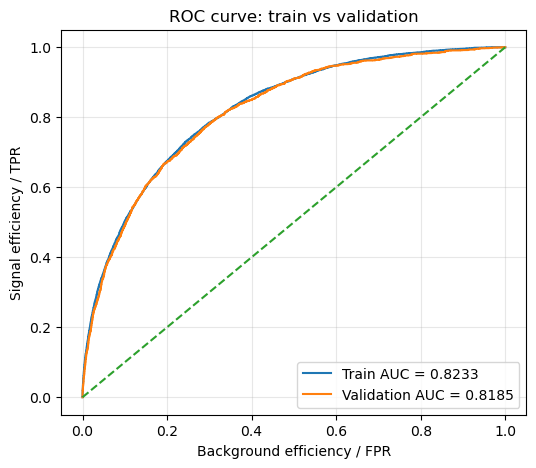

In [21]:
from sklearn.metrics import roc_curve, auc as sklearn_auc


# ============================================================
# Predictions
# ============================================================

pred_train = model.predict(dtrain)
pred_val = model.predict(dval)


# ============================================================
# Train ROC / AUC
# ============================================================

fpr_train, tpr_train, _ = roc_curve(
    y_train,
    pred_train,
    sample_weight=w_train,
)

auc_train = sklearn_auc(
    fpr_train,
    tpr_train,
)


# ============================================================
# Validation ROC / AUC
# ============================================================

fpr_val, tpr_val, _ = roc_curve(
    y_val,
    pred_val,
    sample_weight=w_val,
)

auc_val = sklearn_auc(
    fpr_val,
    tpr_val,
)


# ============================================================
# Print AUC comparison
# ============================================================

print(f"Train AUC      = {auc_train:.6f}")
print(f"Validation AUC = {auc_val:.6f}")
print(f"AUC gap        = {auc_train - auc_val:.6f}")


# ============================================================
# ROC curve: train vs validation
# ============================================================

plt.figure(figsize=(6, 5))

plt.plot(
    fpr_train,
    tpr_train,
    label=f"Train AUC = {auc_train:.4f}",
)

plt.plot(
    fpr_val,
    tpr_val,
    label=f"Validation AUC = {auc_val:.4f}",
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
)

plt.xlabel("Background efficiency / FPR")
plt.ylabel("Signal efficiency / TPR")
plt.title("ROC curve: train vs validation")

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

AUC = 0.8185418286415352


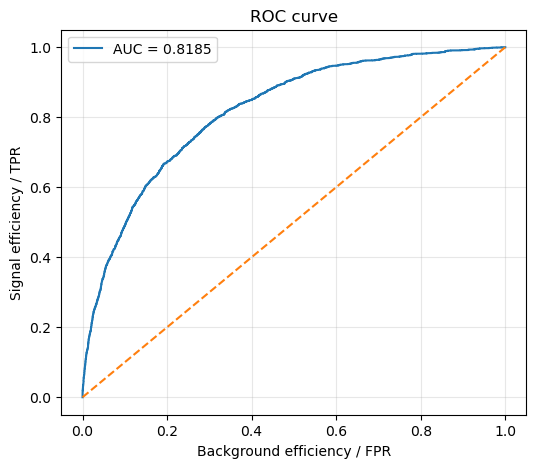

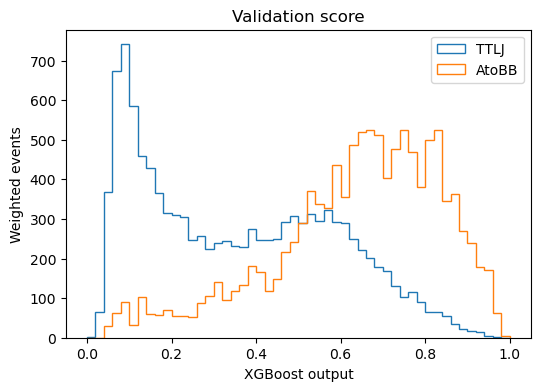

In [22]:
from sklearn.metrics import roc_curve, auc as sklearn_auc

y_pred = model.predict(dval)

fpr, tpr, thresholds = roc_curve(y_val, y_pred, sample_weight=w_val)
auc_val = sklearn_auc(fpr, tpr)
print("AUC =", auc_val)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_val:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Background efficiency / FPR")
plt.ylabel("Signal efficiency / TPR")
plt.title("ROC curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(6,4))
plt.hist(y_pred[y_val.to_numpy() == 0], bins=50, range=(0,1), histtype="step", weights=w_val[y_val == 0], label="TTLJ")
plt.hist(y_pred[y_val.to_numpy() == 1], bins=50, range=(0,1), histtype="step", weights=w_val[y_val == 1], label="AtoBB")
plt.xlabel("XGBoost output")
plt.ylabel("Weighted events")
plt.legend()
plt.title("Validation score")
plt.show()


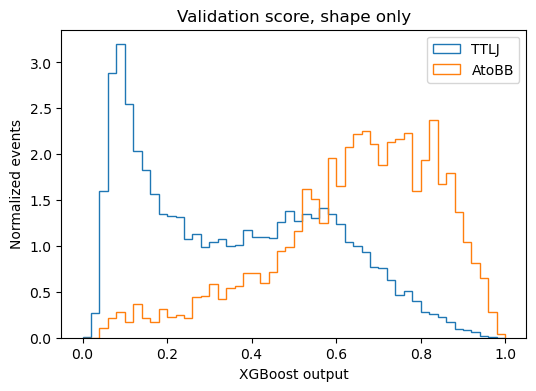

In [23]:
plt.figure(figsize=(6,4))
plt.hist(y_pred[y_val.to_numpy() == 0], bins=50, range=(0,1),
         histtype="step", density=True, label="TTLJ")
plt.hist(y_pred[y_val.to_numpy() == 1], bins=50, range=(0,1),
         histtype="step", density=True, label="AtoBB")
plt.xlabel("XGBoost output")
plt.ylabel("Normalized events")
plt.legend()
plt.title("Validation score, shape only")
plt.show()

## 11. Overtraining check

Compare train vs validation score shapes.


[KS overtraining check]
Signal:     D = 0.0157, p = 0.6213
Background: D = 0.0046, p = 0.8857


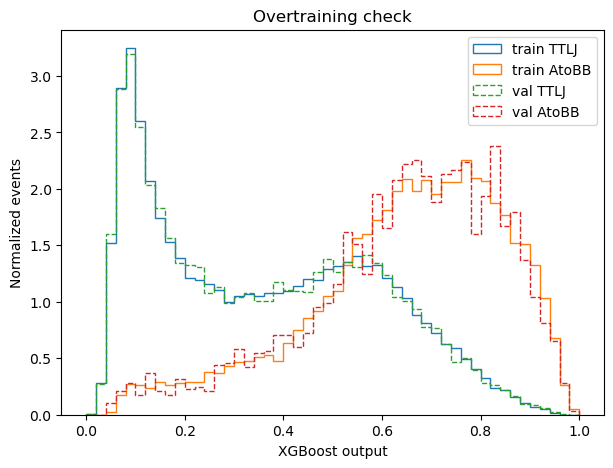

In [24]:
pred_train = model.predict(dtrain)
pred_val = model.predict(dval)

y_train_np = y_train.to_numpy()
y_val_np = y_val.to_numpy()
w_train_np = w_train.to_numpy()
w_val_np = w_val.to_numpy()

# ============================================================
# [ADDED] Kolmogorov-Smirnov overtraining test
#
# Compare:
#   signal train vs signal validation
#   bkg    train vs bkg    validation
#
# Do NOT compare signal vs background here.
# That would measure discrimination, not overtraining.
#
# scipy.stats.ks_2samp is UNWEIGHTED.
# ============================================================

ks_sig = ks_2samp(
    pred_train[y_train_np == 1],
    pred_val[y_val_np == 1],
)

ks_bkg = ks_2samp(
    pred_train[y_train_np == 0],
    pred_val[y_val_np == 0],
)


print("[KS overtraining check]")

print(
    f"Signal:     "
    f"D = {ks_sig.statistic:.4f}, "
    f"p = {ks_sig.pvalue:.4g}"
)

print(
    f"Background: "
    f"D = {ks_bkg.statistic:.4f}, "
    f"p = {ks_bkg.pvalue:.4g}"
)

plt.figure(figsize=(7, 5))
plt.hist(pred_train[y_train_np == 0], bins=50, range=(0, 1), histtype="step", density=True, label="train TTLJ")
plt.hist(pred_train[y_train_np == 1], bins=50, range=(0, 1), histtype="step", density=True, label="train AtoBB")
plt.hist(pred_val[y_val_np == 0], bins=50, range=(0, 1), histtype="step", density=True, linestyle="--", label="val TTLJ")
plt.hist(pred_val[y_val_np == 1], bins=50, range=(0, 1), histtype="step", density=True, linestyle="--", label="val AtoBB")
plt.xlabel("XGBoost output")
plt.ylabel("Normalized events")
plt.title("Overtraining check")
plt.legend()
plt.show()


## 12. Feature importance


              feature         gain
0     bb_mass_min_all  1360.610229
1   bb_mass_at_min_dr   445.656494
2       bb_dr_min_all   204.129379
3       bblnu_mass_12   163.924088
4        lep_top_mass   153.525833
5       bbbW_mass_012   153.396652
6              nBJets   138.288101
7        had_top_mass   105.316551
8            bb_dr_12   101.790176
9     bb_mass_max_all    94.876808
10         bb_mass_12    92.953972
11                 HT    91.533028
12         lep_W_mass    88.156433
13                 ST    84.263199
14           bb_dr_02    76.579941
15              nJets    71.393417
16      bblnu_mass_02    66.762901
17         bb_mass_01    60.216248
18       bbjj_mass_12    59.016644
19      bblnu_mass_01    56.031868
20         bb_mass_02    48.164814
21           bb_dr_01    47.052429
22           lnu_mass    44.683956
23         had_W_mass    44.357838
24       bbjj_mass_01    43.429089
25          best_chi2    40.505722
26             MET_Pt    38.803917
27       bbjj_mass_0

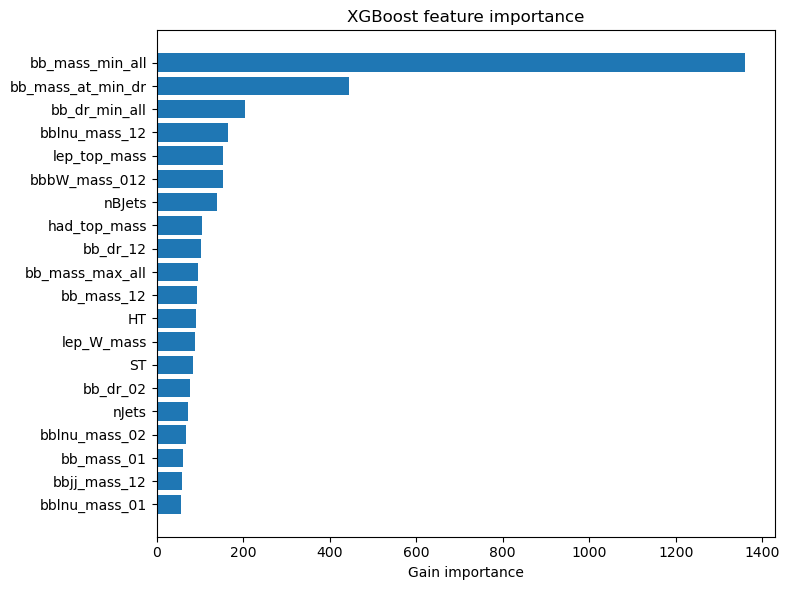

In [25]:
importance = model.get_score(importance_type="gain")
importance_named = []
for key, val in importance.items():
    # key is like f0, f1, ...
    idx = int(key[1:]) if key.startswith("f") else int(key)
    importance_named.append((used_columns[idx], val))
importance_named = sorted(importance_named, key=lambda x: x[1], reverse=True)

imp_df = pd.DataFrame(importance_named, columns=["feature", "gain"])
print(imp_df.head(30))

plt.figure(figsize=(8,6))
plot_df = imp_df.head(20).iloc[::-1]
plt.barh(plot_df["feature"], plot_df["gain"])
plt.xlabel("Gain importance")
plt.title("XGBoost feature importance")
plt.tight_layout()
plt.show()


In [26]:
# ============================================================
# Save ALL training information + validation/overtraining plots
# ============================================================
import os, sys, platform
from datetime import datetime
import sklearn, scipy
from sklearn.metrics import roc_curve, auc as sklearn_auc
from scipy.stats import ks_2samp

# ---------- output directory / tag ----------
PLOT_DIR = f"{MODEL_DIR}/scan_plots_0814_bb3massxx_bblnu3massxx_Amassxx_MA36"
PDF_DIR = f"{PLOT_DIR}/pdf"
os.makedirs(PLOT_DIR, exist_ok=True)
os.makedirs(PDF_DIR, exist_ok=True)

scaler_tag = "none" if SCALER_TYPE is None else str(SCALER_TYPE)
nbkg_tag = "all" if N_BKG is None else str(N_BKG)
tag = f"MHc{int(TARGET_MHc)}_MA{int(TARGET_MA)}_nbkg{nbkg_tag}_boost{NUM_BOOST_ROUND}_{scaler_tag}"

def save_current_results(tag):
    # ---------- predictions / arrays ----------
    pred_train = model.predict(dtrain)
    pred_val = model.predict(dval)
    y_train_np, y_val_np = y_train.to_numpy(), y_val.to_numpy()
    w_train_np, w_val_np = w_train.to_numpy(), w_val.to_numpy()

    # ---------- AUC ----------
    fpr_train, tpr_train, _ = roc_curve(y_train_np, pred_train, sample_weight=w_train_np)
    fpr_val, tpr_val, _ = roc_curve(y_val_np, pred_val, sample_weight=w_val_np)
    auc_train = sklearn_auc(fpr_train, tpr_train)
    auc_val = sklearn_auc(fpr_val, tpr_val)
    auc_gap = auc_train - auc_val

    # ---------- KS: train vs validation, separately for S/B ----------
    # NOTE: scipy ks_2samp is unweighted.
    ks_sig = ks_2samp(pred_train[y_train_np == 1], pred_val[y_val_np == 1])
    ks_bkg = ks_2samp(pred_train[y_train_np == 0], pred_val[y_val_np == 0])

    # ---------- feature importance ----------
    importance = model.get_score(importance_type="gain")
    importance_named = []
    for key, val in importance.items():
        if key in used_columns:
            name = key
        elif key.startswith("f") and key[1:].isdigit():
            idx = int(key[1:])
            name = used_columns[idx] if idx < len(used_columns) else key
        else:
            name = key
        importance_named.append((name, val))
    importance_named = sorted(importance_named, key=lambda x: x[1], reverse=True)
    imp_df = pd.DataFrame(importance_named, columns=["feature", "gain"])
    imp_df.to_csv(f"{PLOT_DIR}/feature_importance_{tag}.csv", index=False)

    # ========================================================
    # 1. Validation-only ROC
    # ========================================================
    plt.figure(figsize=(6,5))
    plt.plot(fpr_val, tpr_val, label=f"Validation AUC = {auc_val:.4f}")
    plt.plot([0,1],[0,1], linestyle="--")
    plt.xlabel("Background efficiency / FPR"); plt.ylabel("Signal efficiency / TPR")
    plt.title(f"Validation ROC: {tag}"); plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
    plt.savefig(f"{PLOT_DIR}/roc_validation_{tag}.png", dpi=150)
    plt.savefig(f"{PDF_DIR}/roc_validation_{tag}.pdf", bbox_inches="tight"); plt.close()

    # ========================================================
    # 2. Train vs validation ROC
    # ========================================================
    plt.figure(figsize=(6,5))
    plt.plot(fpr_train, tpr_train, label=f"Train AUC = {auc_train:.4f}")
    plt.plot(fpr_val, tpr_val, label=f"Validation AUC = {auc_val:.4f}")
    plt.plot([0,1],[0,1], linestyle="--")
    plt.xlabel("Background efficiency / FPR"); plt.ylabel("Signal efficiency / TPR")
    plt.title(f"ROC: train vs validation\nAUC gap = {auc_gap:.4f}")
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
    plt.savefig(f"{PLOT_DIR}/roc_train_vs_val_{tag}.png", dpi=150)
    plt.savefig(f"{PDF_DIR}/roc_train_vs_val_{tag}.pdf", bbox_inches="tight"); plt.close()

    # ========================================================
    # 3. Validation score, weighted
    # ========================================================
    plt.figure(figsize=(6,4))
    plt.hist(pred_val[y_val_np == 0], bins=50, range=(0,1), histtype="step", density=True,
             weights=w_val_np[y_val_np == 0], label="TTLJ")
    plt.hist(pred_val[y_val_np == 1], bins=50, range=(0,1), histtype="step", density=True,
             weights=w_val_np[y_val_np == 1], label="AtoBB")
    plt.xlabel("XGBoost output"); plt.ylabel("Normalized weighted events")
    plt.title(f"Validation score: {tag}"); plt.legend(); plt.tight_layout()
    plt.savefig(f"{PLOT_DIR}/score_validation_weighted_{tag}.png", dpi=150)
    plt.savefig(f"{PDF_DIR}/score_validation_weighted_{tag}.pdf", bbox_inches="tight"); plt.close()

    # ========================================================
    # 4. Validation score, shape only
    # ========================================================
    plt.figure(figsize=(6,4))
    plt.hist(pred_val[y_val_np == 0], bins=50, range=(0,1), histtype="step", density=True, label="TTLJ")
    plt.hist(pred_val[y_val_np == 1], bins=50, range=(0,1), histtype="step", density=True, label="AtoBB")
    plt.xlabel("XGBoost output"); plt.ylabel("Normalized events")
    plt.title(f"Validation score, shape only: {tag}"); plt.legend(); plt.tight_layout()
    plt.savefig(f"{PLOT_DIR}/score_validation_shape_{tag}.png", dpi=150)
    plt.savefig(f"{PDF_DIR}/score_validation_shape_{tag}.pdf", bbox_inches="tight"); plt.close()

    # ========================================================
    # 5. Overtraining check: weighted train vs validation
    # ========================================================
    plt.figure(figsize=(7,5))
    plt.hist(pred_train[y_train_np == 0], bins=50, range=(0,1), histtype="step", density=True,
             weights=w_train_np[y_train_np == 0], label="Train TTLJ")
    plt.hist(pred_train[y_train_np == 1], bins=50, range=(0,1), histtype="step", density=True,
             weights=w_train_np[y_train_np == 1], label="Train AtoBB")
    plt.hist(pred_val[y_val_np == 0], bins=50, range=(0,1), histtype="step", density=True, linestyle="--",
             weights=w_val_np[y_val_np == 0], label="Val TTLJ")
    plt.hist(pred_val[y_val_np == 1], bins=50, range=(0,1), histtype="step", density=True, linestyle="--",
             weights=w_val_np[y_val_np == 1], label="Val AtoBB")
    plt.xlabel("XGBoost output"); plt.ylabel("Normalized weighted events")
    plt.title(f"Overtraining check: {tag}"); plt.legend(); plt.tight_layout()
    plt.savefig(f"{PLOT_DIR}/overtraining_{tag}.png", dpi=150)
    plt.savefig(f"{PDF_DIR}/overtraining_{tag}.pdf", bbox_inches="tight"); plt.close()

    # ========================================================
    # 6. Learning curve: train / validation logloss
    # ========================================================
    train_loss = evals_result["train"]["logloss"]
    val_loss = evals_result["validation"]["logloss"]
    try: best_iteration = int(model.best_iteration)
    except: best_iteration = None
    try: best_score = float(model.best_score)
    except: best_score = None

    plt.figure(figsize=(7,4))
    plt.plot(train_loss, label="Train logloss")
    plt.plot(val_loss, label="Validation logloss")
    if best_iteration is not None:
        plt.axvline(best_iteration, linestyle="--", label=f"Best iteration = {best_iteration}")
    plt.xlabel("Boosting round"); plt.ylabel("Logloss")
    plt.title(f"Learning curve: {tag}"); plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
    plt.savefig(f"{PLOT_DIR}/learning_curve_{tag}.png", dpi=150)
    plt.savefig(f"{PDF_DIR}/learning_curve_{tag}.pdf", bbox_inches="tight"); plt.close()

    # ========================================================
    # 7. KS CDF visualization
    # ========================================================
    def ecdf(x):
        x = np.sort(np.asarray(x))
        return x, np.arange(1, len(x)+1) / len(x)

    plt.figure(figsize=(7,5))
    for arr, label, ls in [
        (pred_train[y_train_np == 1], "Train AtoBB", "-"), (pred_val[y_val_np == 1], "Val AtoBB", "--"),
        (pred_train[y_train_np == 0], "Train TTLJ", "-"), (pred_val[y_val_np == 0], "Val TTLJ", "--")
    ]:
        x, y = ecdf(arr); plt.plot(x, y, linestyle=ls, label=label)
    plt.xlabel("XGBoost output"); plt.ylabel("Empirical CDF")
    plt.title(f"KS check: Signal p={ks_sig.pvalue:.3g}, Bkg p={ks_bkg.pvalue:.3g}")
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
    plt.savefig(f"{PLOT_DIR}/ks_cdf_{tag}.png", dpi=150)
    plt.savefig(f"{PDF_DIR}/ks_cdf_{tag}.pdf", bbox_inches="tight"); plt.close()

    # ========================================================
    # 8. Feature importance
    # ========================================================
    # XGBoost internal feature name -> real feature name
    feature_map = {f"f{i}": feat for i, feat in enumerate(FEATURES)}
    feature_map.update({str(i): feat for i, feat in enumerate(FEATURES)})

    imp_plot_df = imp_df.copy()
    imp_plot_df["feature_name"] = imp_plot_df["feature"].astype(str).map(feature_map)

    # 혹시 이미 실제 이름으로 들어있는 경우도 처리
    imp_plot_df["feature_name"] = imp_plot_df["feature_name"].fillna(
        imp_plot_df["feature"].astype(str)
    )

    # gain 큰 순서 top 20
    plot_df = imp_plot_df.sort_values("gain", ascending=False).head(20).iloc[::-1]

    plt.figure(figsize=(10, 7))
    plt.barh(plot_df["feature_name"], plot_df["gain"])
    plt.xlabel("Gain importance")
    plt.title(f"XGBoost feature importance: {tag}")
    plt.tight_layout()
    plt.savefig(f"{PLOT_DIR}/importance_{tag}.png", dpi=150, bbox_inches="tight")
    plt.close()
    # ========================================================
    # 9. Save ALL training configuration/results to TXT
    # ========================================================
    info_path = f"{PLOT_DIR}/training_info_{tag}.txt"
    early_stopping_rounds = globals().get("EARLY_STOPPING_ROUNDS", 50)
    actual_rounds = len(train_loss)

    # ROOT entry counts from input files (before N_BKG sampling)
    def root_entries(paths):
        result = []
        for path in paths:
            f = ROOT.TFile.Open(path, "READ")
            tree = f.Get(TREE_NAME) if f and not f.IsZombie() else None
            result.append((path, int(tree.GetEntries()) if tree else -1))
            if f: f.Close()
        return result

    sig_root_entries = root_entries(SIG_FILES)
    bkg_root_entries = root_entries(BKG_FILES)

    with open(info_path, "w") as f:
        f.write("========== XGBoost AtoBB Training Record ==========\n")
        f.write(f"Saved at              : {datetime.now().isoformat()}\n")
        f.write(f"Tag                   : {tag}\n")
        f.write(f"Model name            : {globals().get('MODEL_NAME', 'N/A')}\n")
        f.write(f"Tree name             : {TREE_NAME}\n")
        f.write(f"TARGET_MHc            : {TARGET_MHc}\n")
        f.write(f"TARGET_MA             : {TARGET_MA}\n\n")

        f.write("========== Input Samples ==========\n")
        f.write("Signal files:\n")
        for path, n in sig_root_entries: f.write(f"  {path}\n    ROOT entries = {n}\n")
        f.write("Background files:\n")
        for path, n in bkg_root_entries: f.write(f"  {path}\n    ROOT entries = {n}\n")
        f.write(f"N_BKG requested       : {N_BKG}\n")
        f.write(f"Signal after loading  : {len(df_sig)}\n")
        f.write(f"Bkg after limit       : {len(df_bkg)}\n")
        f.write(f"Signal after cleaning : {len(df_sig_clean)}\n")
        f.write(f"Bkg after cleaning    : {len(df_bkg_clean)}\n\n")

        f.write("========== Train / Validation ==========\n")
        f.write(f"Random seed           : {globals().get('RANDOM_SEED', 42)}\n")
        f.write(f"Train entries         : {len(train_df)}\n")
        f.write(f"Validation entries    : {len(val_df)}\n")
        f.write(f"Train signal          : {int((y_train_np == 1).sum())}\n")
        f.write(f"Train background      : {int((y_train_np == 0).sum())}\n")
        f.write(f"Validation signal     : {int((y_val_np == 1).sum())}\n")
        f.write(f"Validation background : {int((y_val_np == 0).sum())}\n")
        f.write(f"Training weight       : {globals().get('WEIGHT_COL', 'weight_train')} -> ml_weight\n")
        f.write(f"Sum train weights     : {w_train_np.sum():.10g}\n")
        f.write(f"Sum validation weights: {w_val_np.sum():.10g}\n\n")

        f.write("========== Preprocessing ==========\n")
        f.write(f"SCALER_TYPE           : {SCALER_TYPE}\n")
        f.write(f"Number of features    : {len(used_columns)}\n")
        f.write("Feature order:\n")
        for i, feat in enumerate(used_columns): f.write(f"  {i:02d}: {feat}\n")

        f.write("\n========== XGBoost Configuration ==========\n")
        f.write(f"NUM_BOOST_ROUND requested : {NUM_BOOST_ROUND}\n")
        f.write(f"Actual rounds run         : {actual_rounds}\n")
        f.write(f"Early stopping rounds     : {early_stopping_rounds}\n")
        f.write(f"Best iteration            : {best_iteration}\n")
        f.write(f"Best score                : {best_score}\n")
        f.write("Parameters:\n")
        for key, value in params.items(): f.write(f"  {key}: {value}\n")

        f.write("\n========== Performance ==========\n")
        f.write(f"Train AUC             : {auc_train:.10f}\n")
        f.write(f"Validation AUC        : {auc_val:.10f}\n")
        f.write(f"AUC gap               : {auc_gap:.10f}\n")
        f.write(f"Final train logloss   : {train_loss[-1]:.10f}\n")
        f.write(f"Final val logloss     : {val_loss[-1]:.10f}\n")
        if best_iteration is not None and best_iteration < len(val_loss):
            f.write(f"Train logloss @ best  : {train_loss[best_iteration]:.10f}\n")
            f.write(f"Val logloss @ best    : {val_loss[best_iteration]:.10f}\n")

        f.write("\n========== KS Overtraining Test ==========\n")
        f.write("NOTE: scipy.stats.ks_2samp is an UNWEIGHTED KS test.\n")
        f.write(f"Signal KS D           : {ks_sig.statistic:.10f}\n")
        f.write(f"Signal KS p-value     : {ks_sig.pvalue:.10g}\n")
        f.write(f"Background KS D       : {ks_bkg.statistic:.10f}\n")
        f.write(f"Background KS p-value : {ks_bkg.pvalue:.10g}\n")

        f.write("\n========== Feature Importance (gain) ==========\n")
        for i, row in imp_df.iterrows(): f.write(f"{i+1:02d}. {row['feature']:<35s} {row['gain']:.10g}\n")

        f.write("\n========== Software ==========\n")
        f.write(f"Python                : {sys.version.replace(chr(10),' ')}\n")
        f.write(f"Platform              : {platform.platform()}\n")
        f.write(f"NumPy                 : {np.__version__}\n")
        f.write(f"Pandas                : {pd.__version__}\n")
        f.write(f"XGBoost               : {xgb.__version__}\n")
        f.write(f"scikit-learn          : {sklearn.__version__}\n")
        f.write(f"SciPy                 : {scipy.__version__}\n")
        f.write(f"ROOT                   : {ROOT.gROOT.GetVersion()}\n")

        f.write("\n========== Saved Files ==========\n")
        for name in [
            f"roc_validation_{tag}.png", f"roc_train_vs_val_{tag}.png",
            f"score_validation_weighted_{tag}.png", f"score_validation_shape_{tag}.png",
            f"overtraining_{tag}.png", f"learning_curve_{tag}.png",
            f"ks_cdf_{tag}.png", f"importance_{tag}.png",
            f"feature_importance_{tag}.csv"
        ]: f.write(f"  {name}\n")

    print("\n========== SAVED ==========")
    print("Directory      :", PLOT_DIR)
    print("Training info  :", info_path)
    print("Feature CSV    :", f"{PLOT_DIR}/feature_importance_{tag}.csv")
    print(f"Train AUC      : {auc_train:.6f}")
    print(f"Validation AUC : {auc_val:.6f}")
    print(f"AUC gap        : {auc_gap:.6f}")
    print(f"Signal KS      : D={ks_sig.statistic:.4f}, p={ks_sig.pvalue:.4g}")
    print(f"Background KS  : D={ks_bkg.statistic:.4f}, p={ks_bkg.pvalue:.4g}")
    print("Best iteration :", best_iteration)
    print("Scaler         :", SCALER_TYPE)
    return auc_val

auc_val = save_current_results(tag)


========== SAVED ==========
Directory      : /data9/Users/eunsu/MachineLearning/models/scan_plots_0814_bb3massxx_bblnu3massxx_Amassxx_MA36
Training info  : /data9/Users/eunsu/MachineLearning/models/scan_plots_0814_bb3massxx_bblnu3massxx_Amassxx_MA36/training_info_MHc130_MA36_nbkg100000_boost500_none.txt
Feature CSV    : /data9/Users/eunsu/MachineLearning/models/scan_plots_0814_bb3massxx_bblnu3massxx_Amassxx_MA36/feature_importance_MHc130_MA36_nbkg100000_boost500_none.csv
Train AUC      : 0.823297
Validation AUC : 0.818542
AUC gap        : 0.004755
Signal KS      : D=0.0157, p=0.6213
Background KS  : D=0.0046, p=0.8857
Best iteration : 494
Scaler         : None


## 13. Export to ONNX

This creates `xgboost_atobb_ttlJ.onnx` and a JSON file containing the exact feature order.

The C++ inference input vector **must use this exact order**.


In [27]:
from onnxmltools.convert.common.data_types import FloatTensorType

initial_type = [("input", FloatTensorType([None, len(used_columns)]))]
onnx_model = convert_xgboost_booster(model, initial_types=initial_type, target_opset=12)
onnx.save_model(onnx_model, ONNX_PATH)

metadata = {
    "features": used_columns,
    "feature_indices": {name: i for i, name in enumerate(used_columns)},
    # ========================================================
    # [ADDED]
    # This classifier is explicitly conditioned on this
    # reconstructed MA hypothesis.
    # ========================================================
    "target_ma": TARGET_MA,
    
    "scaler_type": SCALER_TYPE,
    "n_bkg": N_BKG,
    "num_boost_round": NUM_BOOST_ROUND,
    "params": params,
    "auc": float(auc_val),
}

with open(FEATURE_JSON_PATH, "w") as f:
    json.dump(metadata, f, indent=4)

if scaler is not None:
    with open(SCALER_PICKLE_PATH, "wb") as f:
        pickle.dump(scaler, f)

    scaler_json = {
        "scaler_type": SCALER_TYPE,
        "features": used_columns,
    }
    if SCALER_TYPE == "standard":
        scaler_json["mean"] = scaler.mean_.tolist()
        scaler_json["scale"] = scaler.scale_.tolist()
    elif SCALER_TYPE == "minmax":
        scaler_json["min"] = scaler.min_.tolist()
        scaler_json["scale"] = scaler.scale_.tolist()
        scaler_json["data_min"] = scaler.data_min_.tolist()
        scaler_json["data_max"] = scaler.data_max_.tolist()

    with open(SCALER_JSON_PATH, "w") as f:
        json.dump(scaler_json, f, indent=4)

print("Saved ONNX:", ONNX_PATH)
print("Saved feature metadata:", FEATURE_JSON_PATH)
print("Saved scaler json:", SCALER_JSON_PATH)
print("Saved scaler pickle:", SCALER_PICKLE_PATH)

Saved ONNX: /data9/Users/eunsu/MachineLearning/models/xgboost_atobb_MHc130_MA36_ttlj.onnx
Saved feature metadata: /data9/Users/eunsu/MachineLearning/models/xgboost_atobb_MHc130_MA36_ttlj_features.json
Saved scaler json: /data9/Users/eunsu/MachineLearning/models/xgboost_atobb_MHc130_MA36_ttlj_scaler.json
Saved scaler pickle: /data9/Users/eunsu/MachineLearning/models/xgboost_atobb_MHc130_MA36_ttlj_scaler.pkl


## 14. Validate ONNX output against XGBoost output

This checks that the exported ONNX model gives the same score as the original XGBoost model.


ONNX inputs: [<onnxruntime.capi.onnxruntime_pybind11_state.NodeArg object at 0x7f7c1ac1dcf0>]
ONNX outputs: [<onnxruntime.capi.onnxruntime_pybind11_state.NodeArg object at 0x7f7c1af287b0>, <onnxruntime.capi.onnxruntime_pybind11_state.NodeArg object at 0x7f7c1af1eef0>]
0 <class 'numpy.ndarray'> (22842,)
1 <class 'numpy.ndarray'> (22842, 2)
ONNX pred ready: (22842,)
max |xgb - onnx| = 4.4703484e-07


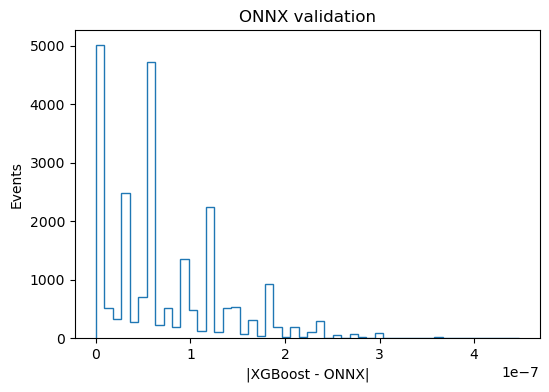

In [28]:
import onnxruntime as ort

sess = ort.InferenceSession(ONNX_PATH, providers=["CPUExecutionProvider"])
print("ONNX inputs:", sess.get_inputs())
print("ONNX outputs:", sess.get_outputs())

X_val_np = X_val.to_numpy(dtype=np.float32)
onnx_outputs = sess.run(None, {"input": X_val_np})

# For binary:logistic conversion, output name/shape can differ by package version.
# Print shapes first.
for i, out in enumerate(onnx_outputs):
    print(i, type(out), getattr(out, "shape", None))

# Try common cases.
y_pred_onnx = None
if len(onnx_outputs) == 1:
    y_pred_onnx = np.asarray(onnx_outputs[0]).reshape(-1)
else:
    # Often: labels, probabilities. probabilities may be array or list of dicts.
    prob = onnx_outputs[-1]
    if isinstance(prob, list):
        y_pred_onnx = np.array([p[1] if 1 in p else p.get("1") for p in prob], dtype=float)
    else:
        prob = np.asarray(prob)
        if prob.ndim == 2 and prob.shape[1] >= 2:
            y_pred_onnx = prob[:, 1]
        else:
            y_pred_onnx = prob.reshape(-1)

print("ONNX pred ready:", y_pred_onnx.shape)
print("max |xgb - onnx| =", np.max(np.abs(y_pred - y_pred_onnx)))

plt.figure(figsize=(6,4))
plt.hist(np.abs(y_pred - y_pred_onnx), bins=50, histtype="step")
plt.xlabel("|XGBoost - ONNX|")
plt.ylabel("Events")
plt.title("ONNX validation")
plt.show()


## 15. C++ inference note

For SKNano C++ inference, use the exact feature order saved in `xgboost_atobb_ttlJ_features.json`.

The input shape should be:

```cpp
input_shape_xgboost["input"] = {1, N_FEATURES};
```

where `N_FEATURES` is printed above.
